# Analisi esplorativa MetroPT-3

Questo notebook esamina struttura, qualità e comportamento temporale della telemetria MetroPT-3. L'obiettivo è comprendere i dati e descrivere le quattro finestre di guasto documentate. La logica definitiva della pipeline verrà successivamente trasferita in moduli Python testabili.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("MetroPT3(AirCompressor).csv")
df

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1516943,15169430,2020-09-01 03:59:10,-0.014,8.918,8.906,-0.022,8.918,59.675,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516944,15169440,2020-09-01 03:59:20,-0.014,8.904,8.888,-0.020,8.904,59.600,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516945,15169450,2020-09-01 03:59:30,-0.014,8.890,8.876,-0.022,8.892,59.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516946,15169460,2020-09-01 03:59:40,-0.012,8.876,8.864,-0.022,8.878,59.550,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1516948 entries, 0 to 1516947
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Unnamed: 0       1516948 non-null  int64  
 1   timestamp        1516948 non-null  object 
 2   TP2              1516948 non-null  float64
 3   TP3              1516948 non-null  float64
 4   H1               1516948 non-null  float64
 5   DV_pressure      1516948 non-null  float64
 6   Reservoirs       1516948 non-null  float64
 7   Oil_temperature  1516948 non-null  float64
 8   Motor_current    1516948 non-null  float64
 9   COMP             1516948 non-null  float64
 10  DV_eletric       1516948 non-null  float64
 11  Towers           1516948 non-null  float64
 12  MPG              1516948 non-null  float64
 13  LPS              1516948 non-null  float64
 14  Pressure_switch  1516948 non-null  float64
 15  Oil_level        1516948 non-null  float64
 16  Caudal_impulses  1

## Struttura, copertura temporale e qualità dei dati

In [4]:
df.shape

(1516948, 17)

In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [6]:
df.columns.tolist()

['Unnamed: 0',
 'timestamp',
 'TP2',
 'TP3',
 'H1',
 'DV_pressure',
 'Reservoirs',
 'Oil_temperature',
 'Motor_current',
 'COMP',
 'DV_eletric',
 'Towers',
 'MPG',
 'LPS',
 'Pressure_switch',
 'Oil_level',
 'Caudal_impulses']

In [7]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [8]:
df["timestamp"].agg(["min", "max"])

min   2020-02-01 00:00:00
max   2020-09-01 03:59:50
Name: timestamp, dtype: datetime64[ns]

In [9]:
df["timestamp"].diff().value_counts().head()

timestamp
0 days 00:00:10    1337521
0 days 00:00:09     128277
0 days 00:00:12      38321
0 days 00:00:13       7988
0 days 00:00:11       4471
Name: count, dtype: int64

In [10]:
df.isna().sum()

Unnamed: 0         0
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64

In [11]:
df["timestamp"].duplicated().sum()

np.int64(0)

Il DataFrame contiene **1.516.948 righe e 17 colonne** e copre il periodo dal 1 febbraio 2020 al 1 settembre 2020.

- Il PDF descrive il dataset originale con una frequenza di 1 Hz, cioè una misura al secondo.
- Nel CSV locale l'intervallo prevalente tra timestamp consecutivi è di 10 secondi, equivalente a circa 0,1 Hz.
- Tra i cinque intervalli più frequenti compaiono 9, 10, 11, 12 e 13 secondi.
- Non sono presenti valori mancanti né timestamp duplicati.

Questi risultati descrivono il file locale senza assumere che coincida perfettamente con la frequenza dichiarata nella documentazione.

## Sensori analogici e digitali

In [12]:
analogici = [
    "TP2", 
    "TP3", 
    "H1", 
    "DV_pressure", 
    "Reservoirs", 
    "Motor_current", 
    "Oil_temperature"
    ]

digitali = [
    "COMP", 
    "DV_eletric", 
    "Towers", 
    "MPG", 
    "LPS",
    "Pressure_switch", 
    "Oil_level", 
    "Caudal_impulses"
]

### Verifica dei valori dei sensori digitali

Controlliamo che ogni sensore digitale contenga soltanto i valori binari 0 e 1 e ne misuriamo la percentuale di attivazione.

In [13]:
df[digitali].agg(["max","min","nunique"]).T

,max,min,nunique
COMP,1.0,0.0,2.0
DV_eletric,1.0,0.0,2.0
Towers,1.0,0.0,2.0
MPG,1.0,0.0,2.0
LPS,1.0,0.0,2.0
Pressure_switch,1.0,0.0,2.0
Oil_level,1.0,0.0,2.0
Caudal_impulses,1.0,0.0,2.0


In [14]:
(df[digitali].mean() * 100).sort_values(ascending=False)

Pressure_switch    99.143675
Caudal_impulses    93.710661
Towers             91.984827
Oil_level          90.415558
COMP               83.695684
MPG                83.266401
DV_eletric         16.061065
LPS                 0.342002
dtype: float64

In [15]:
df[digitali] = df[digitali].astype(int)

In [16]:
df[analogici].describe().T

,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0,1.367826,3.250930,-0.032,-0.014,-0.012,-0.0100,10.676
TP3,1516948.0,8.984611,0.639095,0.730,8.492,8.960,9.4920,10.302
H1,1516948.0,7.568155,3.333200,-0.036,8.254,8.784,9.3740,10.288
DV_pressure,1516948.0,0.055956,0.382402,-0.032,-0.022,-0.020,-0.0180,9.844
Reservoirs,1516948.0,8.985233,0.638307,0.712,8.494,8.960,9.4920,10.300
Motor_current,1516948.0,2.050171,2.302053,0.020,0.040,0.045,3.8075,9.295
Oil_temperature,1516948.0,62.644182,6.516261,15.400,57.775,62.700,67.2500,89.050


### Lettura delle statistiche descrittive

La deviazione standard (`std`) misura quanto i valori si disperdono rispetto alla media. I quartili (`25%`, `50%` e `75%`) descrivono invece come sono distribuite le osservazioni ordinate.

- **TP2:** almeno il 75% delle osservazioni è vicino a zero, con piccoli valori negativi compatibili con rumore o calibrazione del sensore. Le osservazioni rimanenti raggiungono circa 10,7 bar. In questa fase non correggiamo o eliminiamo i valori negativi.
- **TP3:** rimane generalmente tra 8,5 e 9,5 bar, ma il minimo di 0,73 mostra che esistono periodi con pressioni molto più basse. La sola statistica descrittiva non permette di stabilirne la causa.
- **H1:** i quartili sono superiori a 8 bar, mentre il minimo è vicino a zero. Il sensore presenta quindi almeno due regimi distinti.
- **DV_pressure:** almeno il 75% dei valori è vicino a zero, mentre il massimo raggiunge 9,84 bar. Il segnale sembra attivarsi in periodi limitati.
- **Reservoirs:** presenta statistiche molto simili a TP3. La successiva analisi temporale verifica quanto i due segnali coincidano e quando divergano.
- **Motor_current:** alterna valori vicini a zero e diversi regimi operativi. La documentazione associa valori prossimi a 0 A allo spegnimento, 4 A al funzionamento senza carico, 7 A al funzionamento sotto carico e 9 A all'avvio. In questa EDA osserviamo i regimi senza creare nuove caratteristiche.
- **Oil_temperature:** ha media 62,6 °C e deviazione standard 6,5 °C; varia meno rapidamente delle pressioni, ma copre un intervallo ampio tra 15,4 e 89,1 °C.

## Distribuzione dei sensori analogici

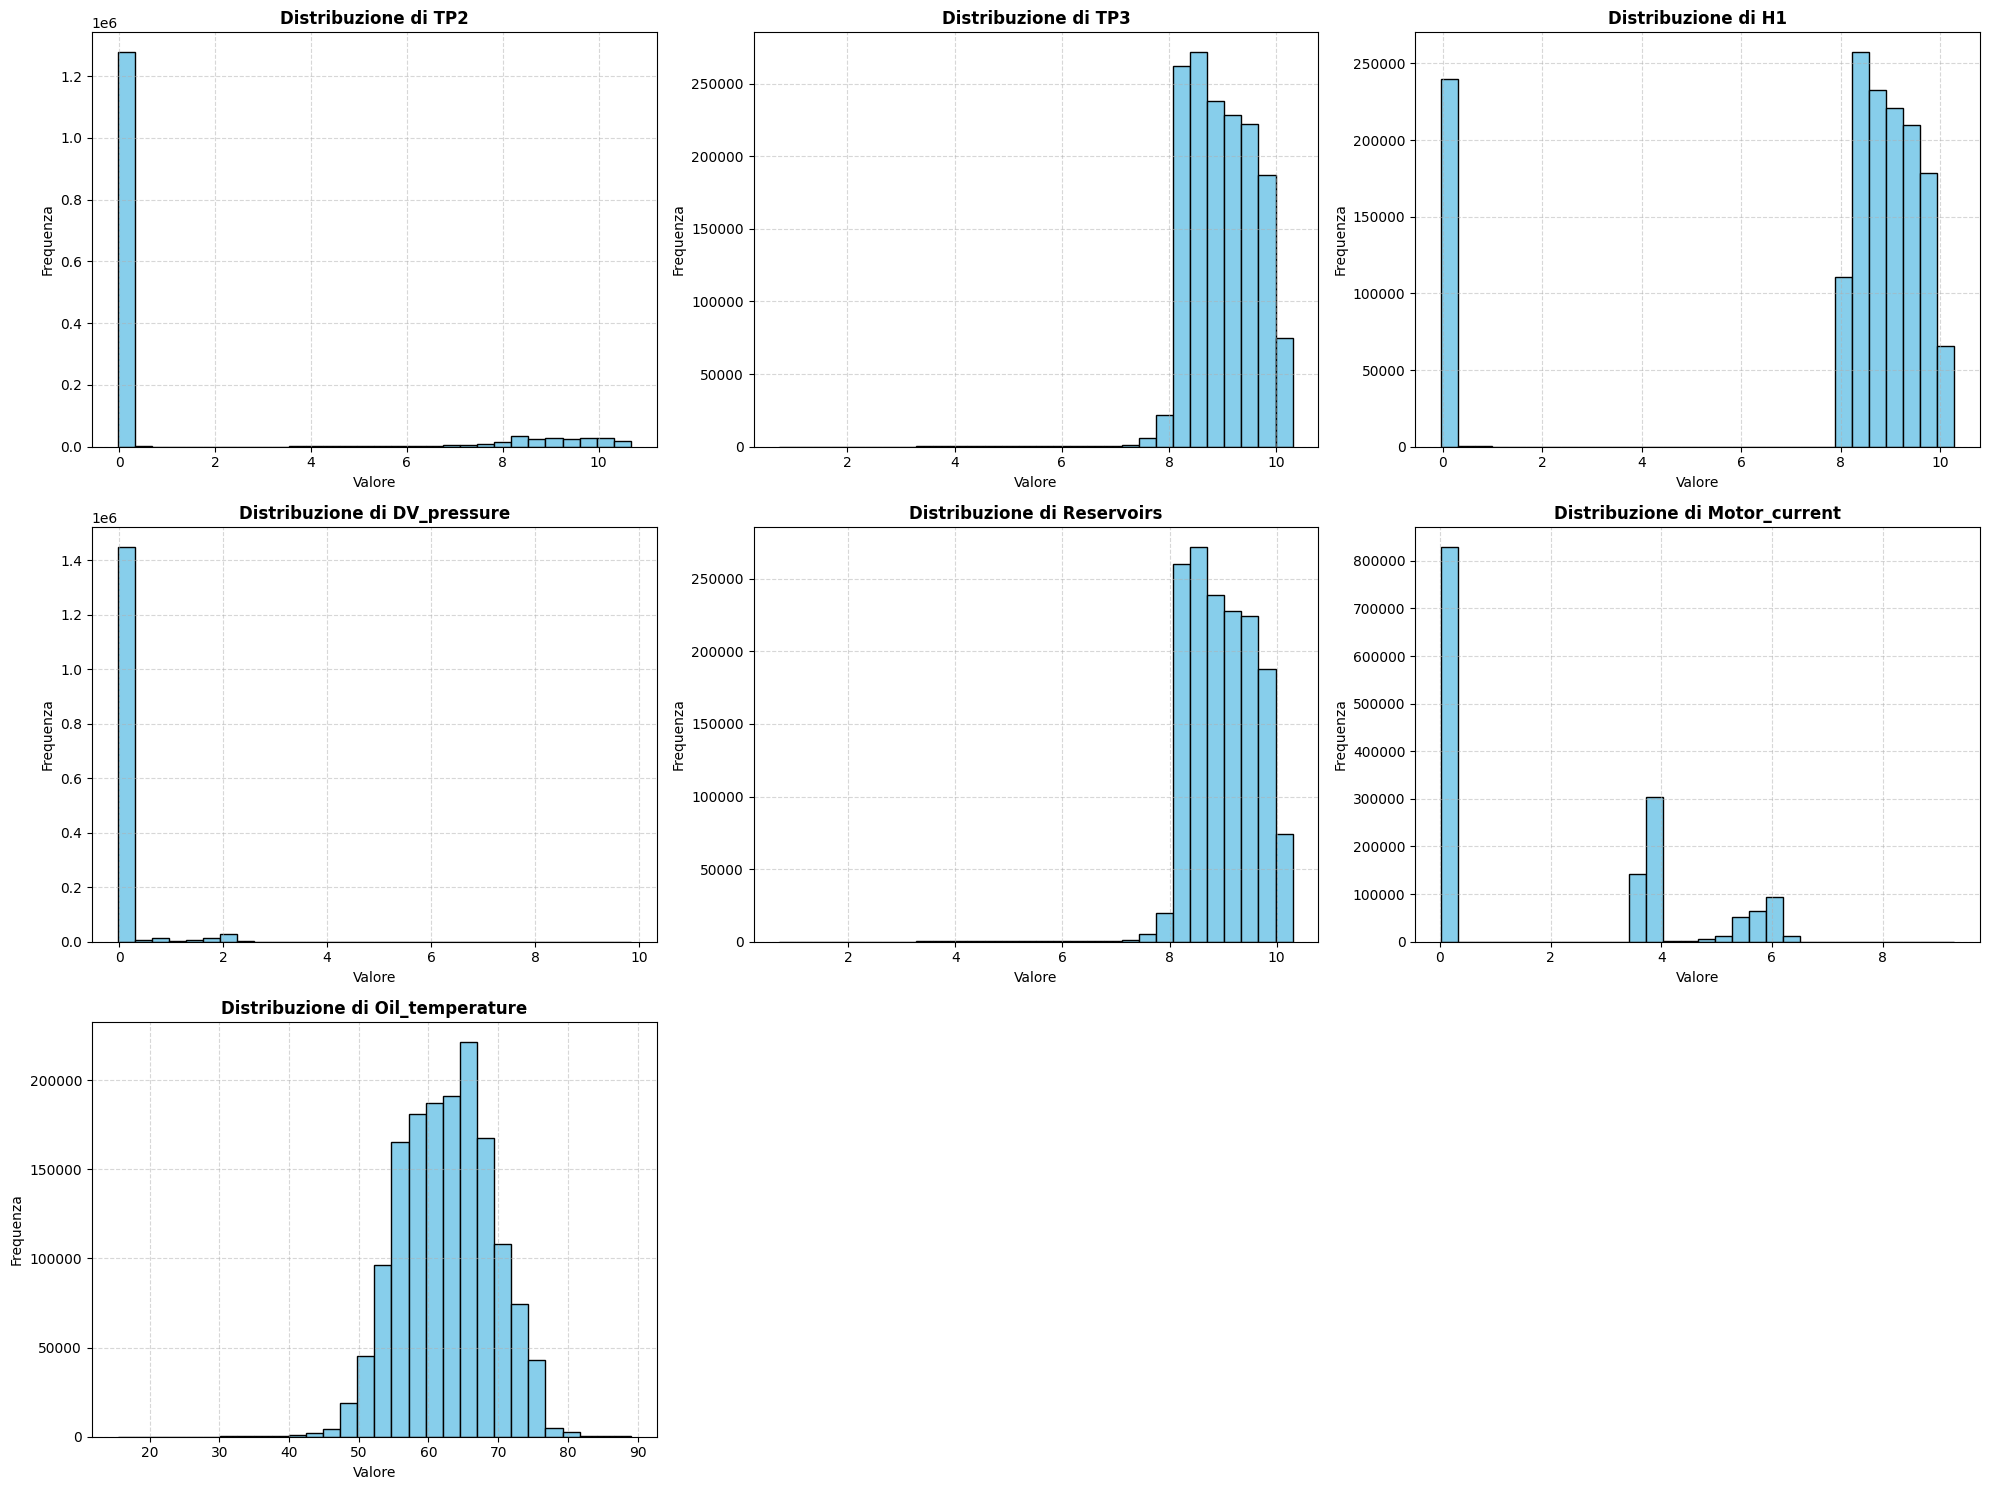

In [17]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

axes = axes.flatten()

for i, col in enumerate(analogici):
    axes[i].hist(df[col], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribuzione di {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valore')
    axes[i].set_ylabel('Frequenza')
    axes[i].grid(True, linestyle='--', alpha=0.5)

for j in range(len(analogici), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

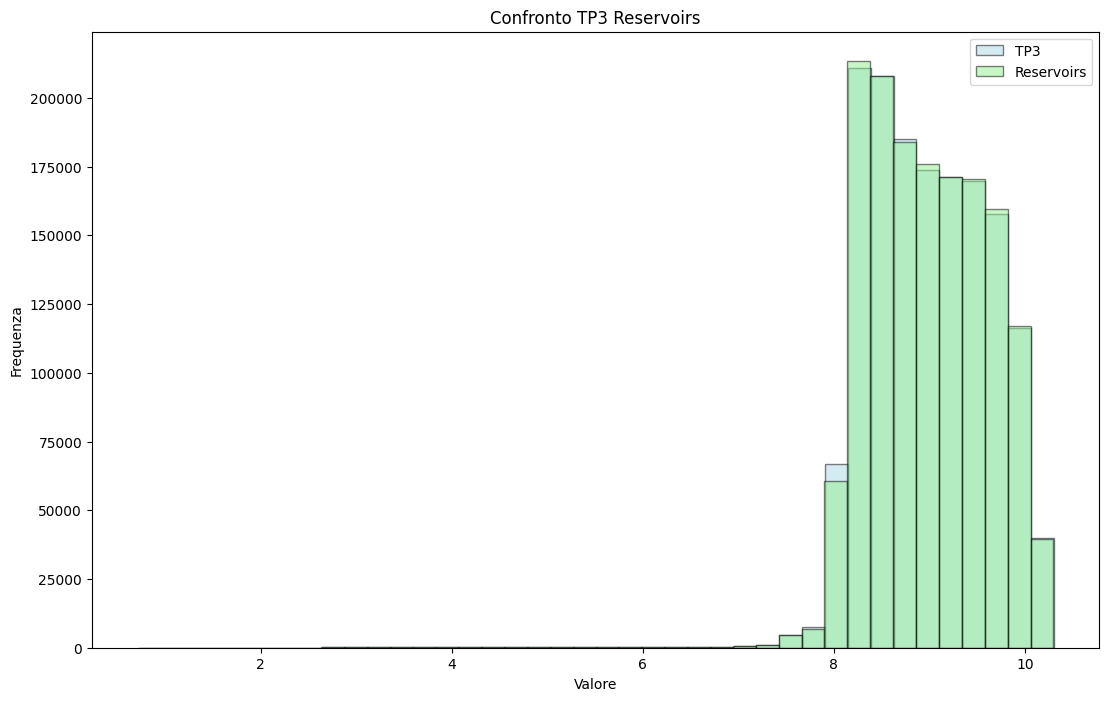

In [18]:
plt.figure(figsize=(13, 8))
plt.hist (df["TP3"], bins=40, edgecolor = "black", color="lightblue", alpha=0.5, label= "TP3")
plt.hist (df["Reservoirs"], bins=40, edgecolor = "black", color="lightgreen", alpha=0.5, label= "Reservoirs")

plt.legend()
plt.title('Confronto TP3 Reservoirs')
plt.xlabel('Valore')
plt.ylabel('Frequenza')
plt.show()

In [19]:
df["timestamp"]

0         2020-02-01 00:00:00
1         2020-02-01 00:00:10
2         2020-02-01 00:00:19
3         2020-02-01 00:00:29
4         2020-02-01 00:00:39
                  ...        
1516943   2020-09-01 03:59:10
1516944   2020-09-01 03:59:20
1516945   2020-09-01 03:59:30
1516946   2020-09-01 03:59:40
1516947   2020-09-01 03:59:50
Name: timestamp, Length: 1516948, dtype: datetime64[ns]

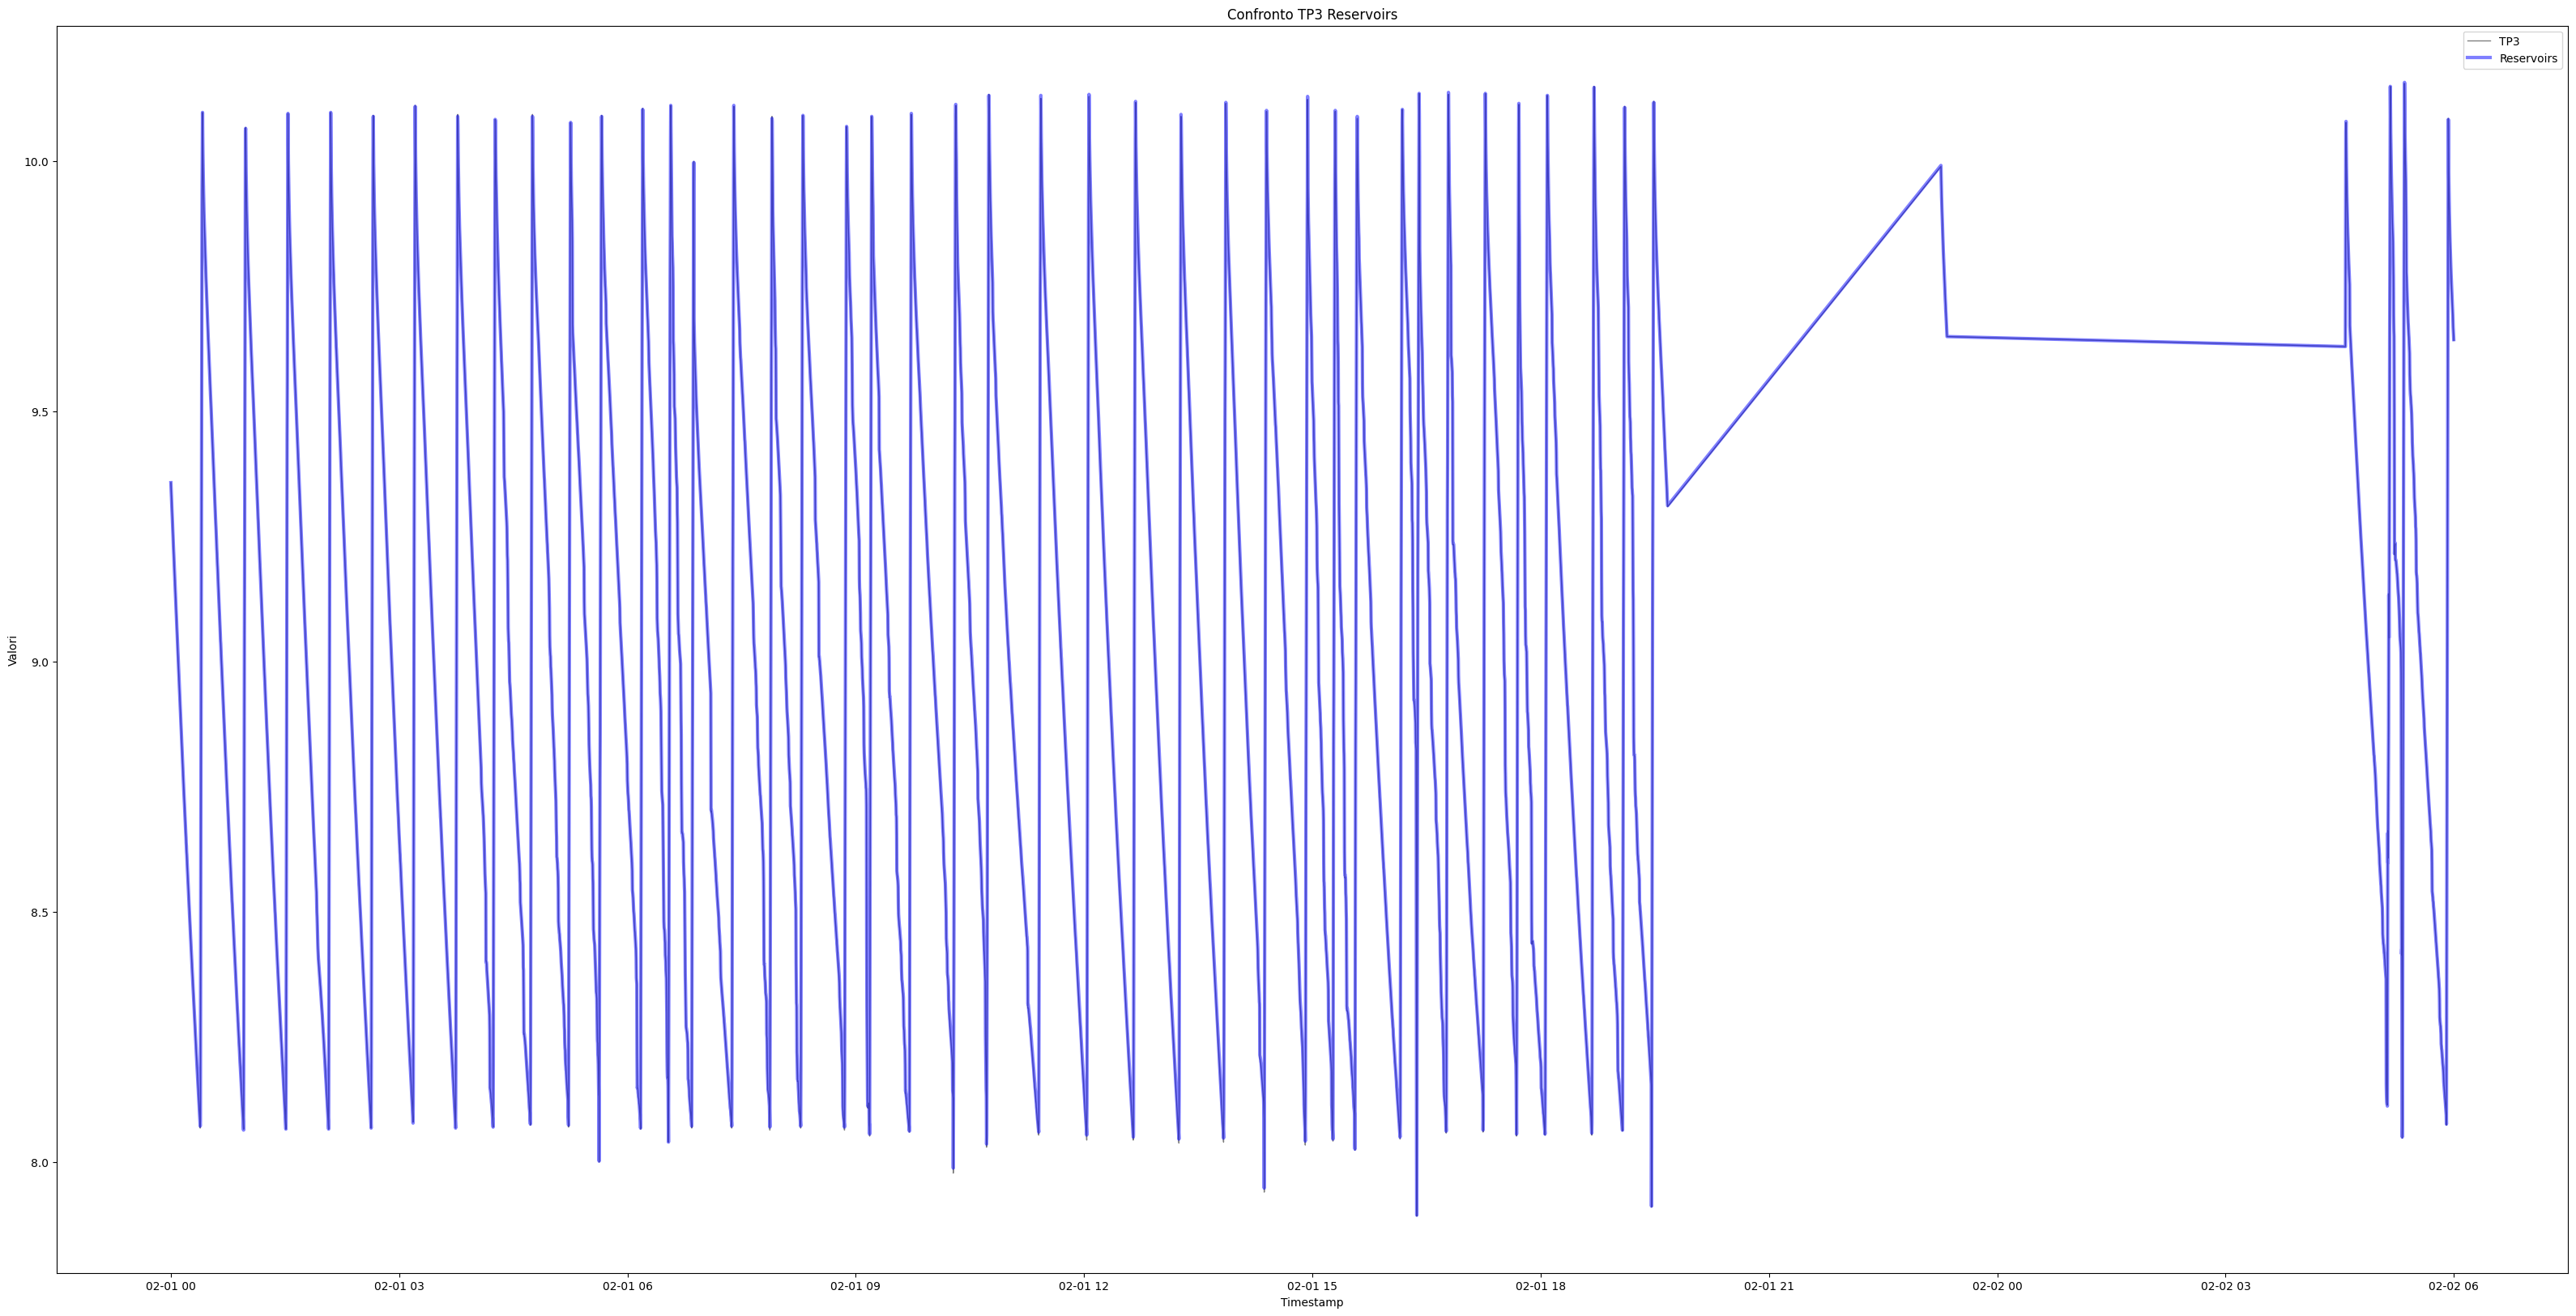

In [20]:
start_date = '2020-02-01 00:00:00'
end_date = '2020-02-02 06:00:00'

df_sub = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

plt.figure(figsize=(40, 20))
plt.plot (df_sub['timestamp'], df_sub['TP3'], linewidth = 1, color="black", alpha=0.5, label= "TP3")
plt.plot (df_sub['timestamp'], df_sub['Reservoirs'], linewidth = 3, color="blue", alpha=0.5, label= "Reservoirs")

plt.legend()
plt.title('Confronto TP3 Reservoirs')
plt.xlabel('Timestamp')
plt.ylabel('Valori')
plt.show()

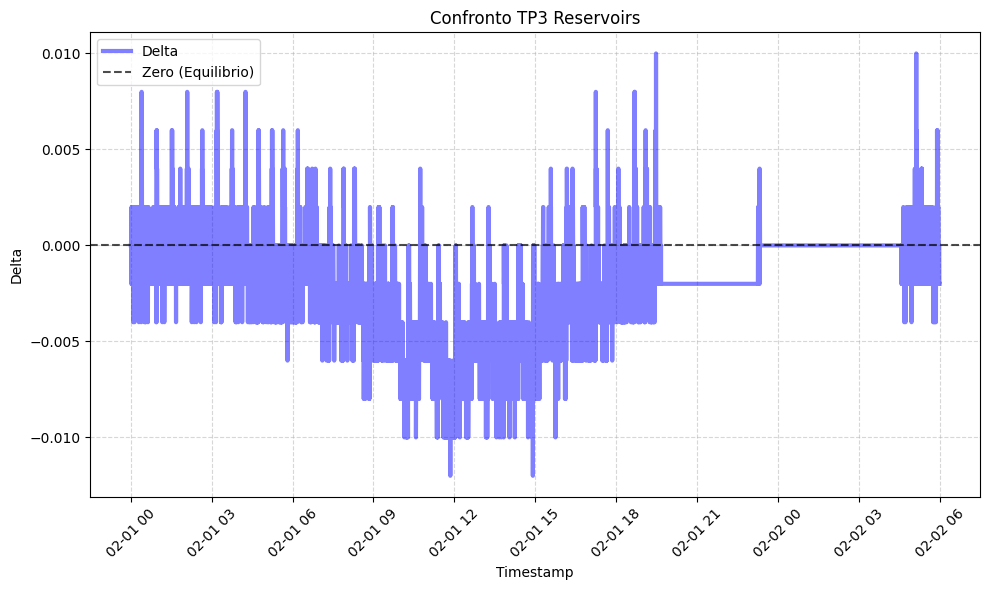

In [21]:
df["delta"] = df["TP3"]-df["Reservoirs"]

df_sub = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

plt.figure(figsize=(10, 6))
plt.plot (df_sub['timestamp'], df_sub['delta'], linewidth = 3, color="blue", alpha=0.5, label= "Delta")

plt.axhline(0, color='black', linestyle='--', alpha=0.7, label='Zero (Equilibrio)')

plt.legend()
plt.title('Confronto TP3 Reservoirs')
plt.xlabel('Timestamp')
plt.ylabel('Delta')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


TP3 e Reservoirs risultano quasi sovrapposti nel grafico temporale. Calcoliamo quindi la loro differenza per quantificare le divergenze che il grafico rende difficili da distinguere.

In [22]:
df["delta"].describe().T

count    1.516948e+06
mean    -6.227425e-04
std      2.451727e-03
min     -1.820000e-01
25%     -2.000000e-03
50%      0.000000e+00
75%      0.000000e+00
max      2.800000e-02
Name: delta, dtype: float64

In [23]:
nullo = (df[df["delta"] == 0]["delta"].count() / len(df)) * 100
minore = (df[df["delta"] < 0]["delta"].count() / len(df)) * 100
maggiore = (df[df["delta"] > 0]["delta"].count() / len(df)) * 100

valori = [nullo, maggiore, minore]
print(nullo, maggiore, minore)

33.158288880040715 22.47855562616517 44.36315549379412


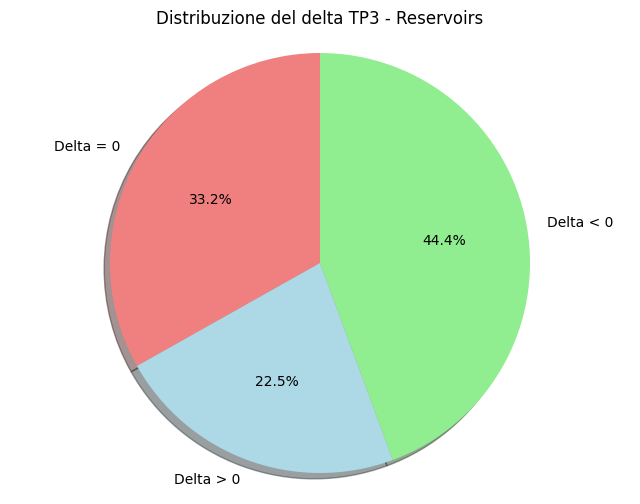

In [24]:
valori = [nullo, maggiore, minore]

plt.figure(figsize=(8, 6))
plt.pie(
    valori,
    labels=["Delta = 0", "Delta > 0", "Delta < 0"],
    autopct="%1.1f%%",
    colors=["lightcoral", "lightblue", "lightgreen"],
    startangle=90,
    shadow=True,
)
plt.title("Distribuzione del delta TP3 - Reservoirs")
plt.axis("equal")
plt.show()

Un delta pari a zero indica che TP3 e Reservoirs coincidono. Un delta negativo indica che Reservoirs è maggiore di TP3; un delta positivo indica il contrario. Nel dataset completo il delta è nullo nel 33,16% delle osservazioni, negativo nel 44,36% e positivo nel 22,48%. I segnali sono quindi molto simili, ma non identici.

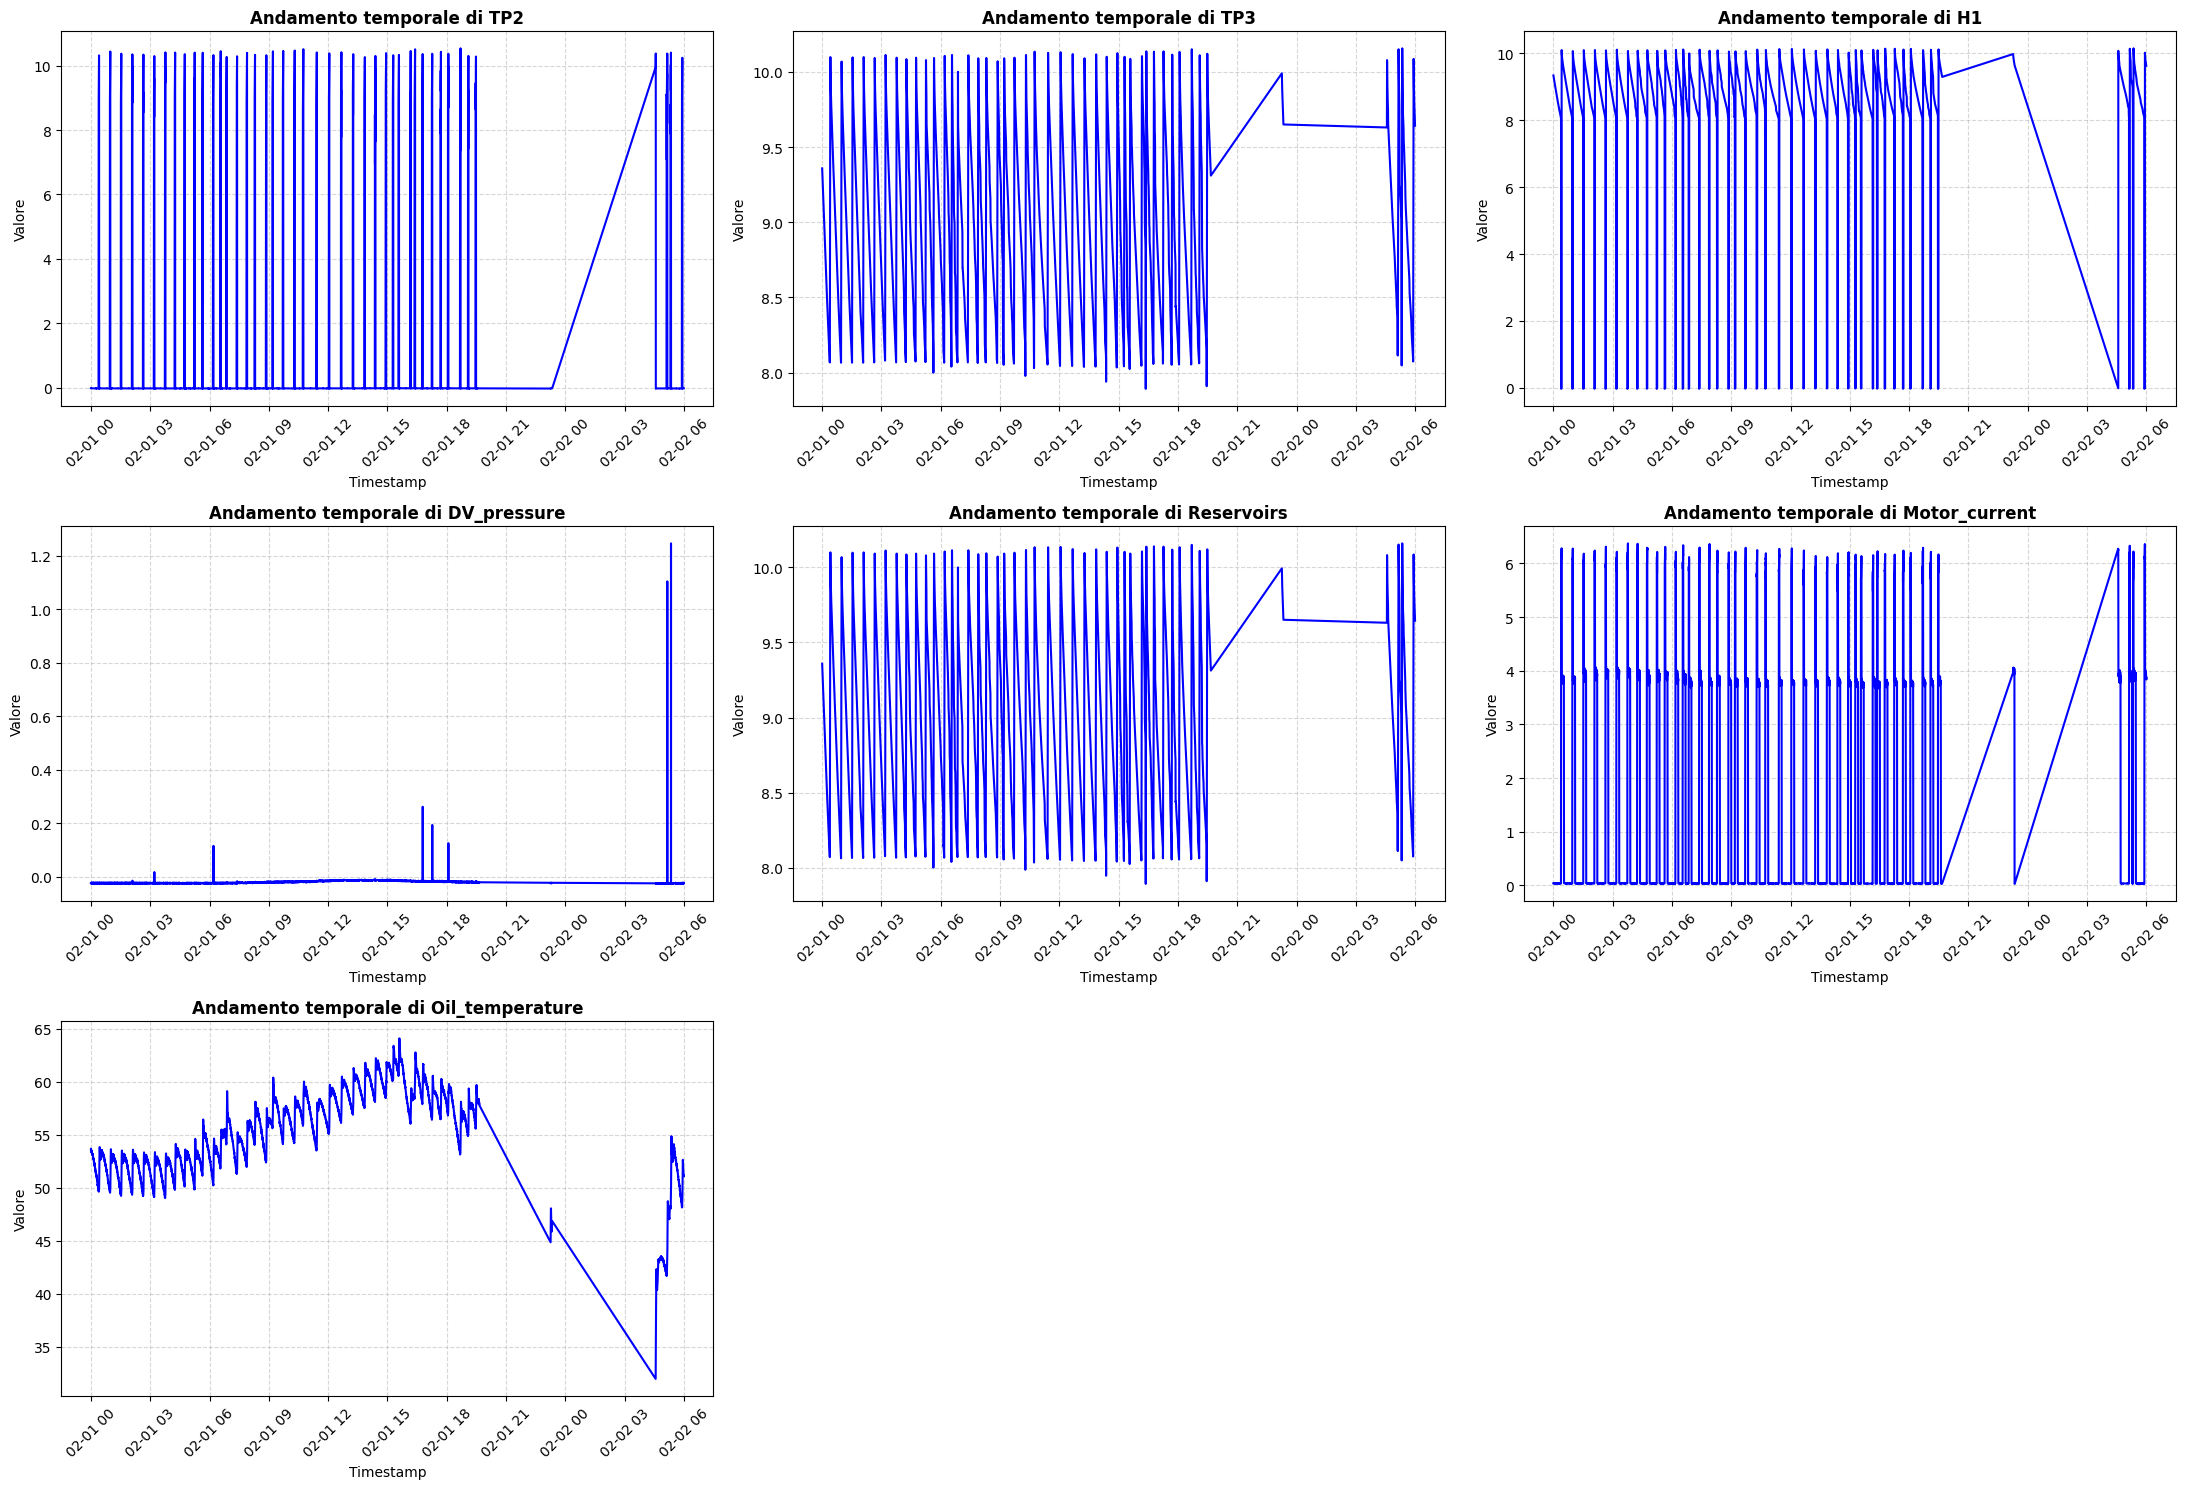

In [25]:
import matplotlib.pyplot as plt
import numpy as np

df_sub = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

fig, axes = plt.subplots(3, 3, figsize=(22, 15))

axes = axes.flatten()

for i, col in enumerate(analogici):
    # CORREZIONE: df_sub[col] SENZA VIRGOLETTE
    axes[i].plot(df_sub['timestamp'], df_sub[col], color='blue', linewidth=1.5)
    axes[i].set_title(f'Andamento temporale di {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Timestamp')
    axes[i].set_ylabel('Valore')
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Ruota le date sull'asse X di 45 gradi per non sovrapporle
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(analogici), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

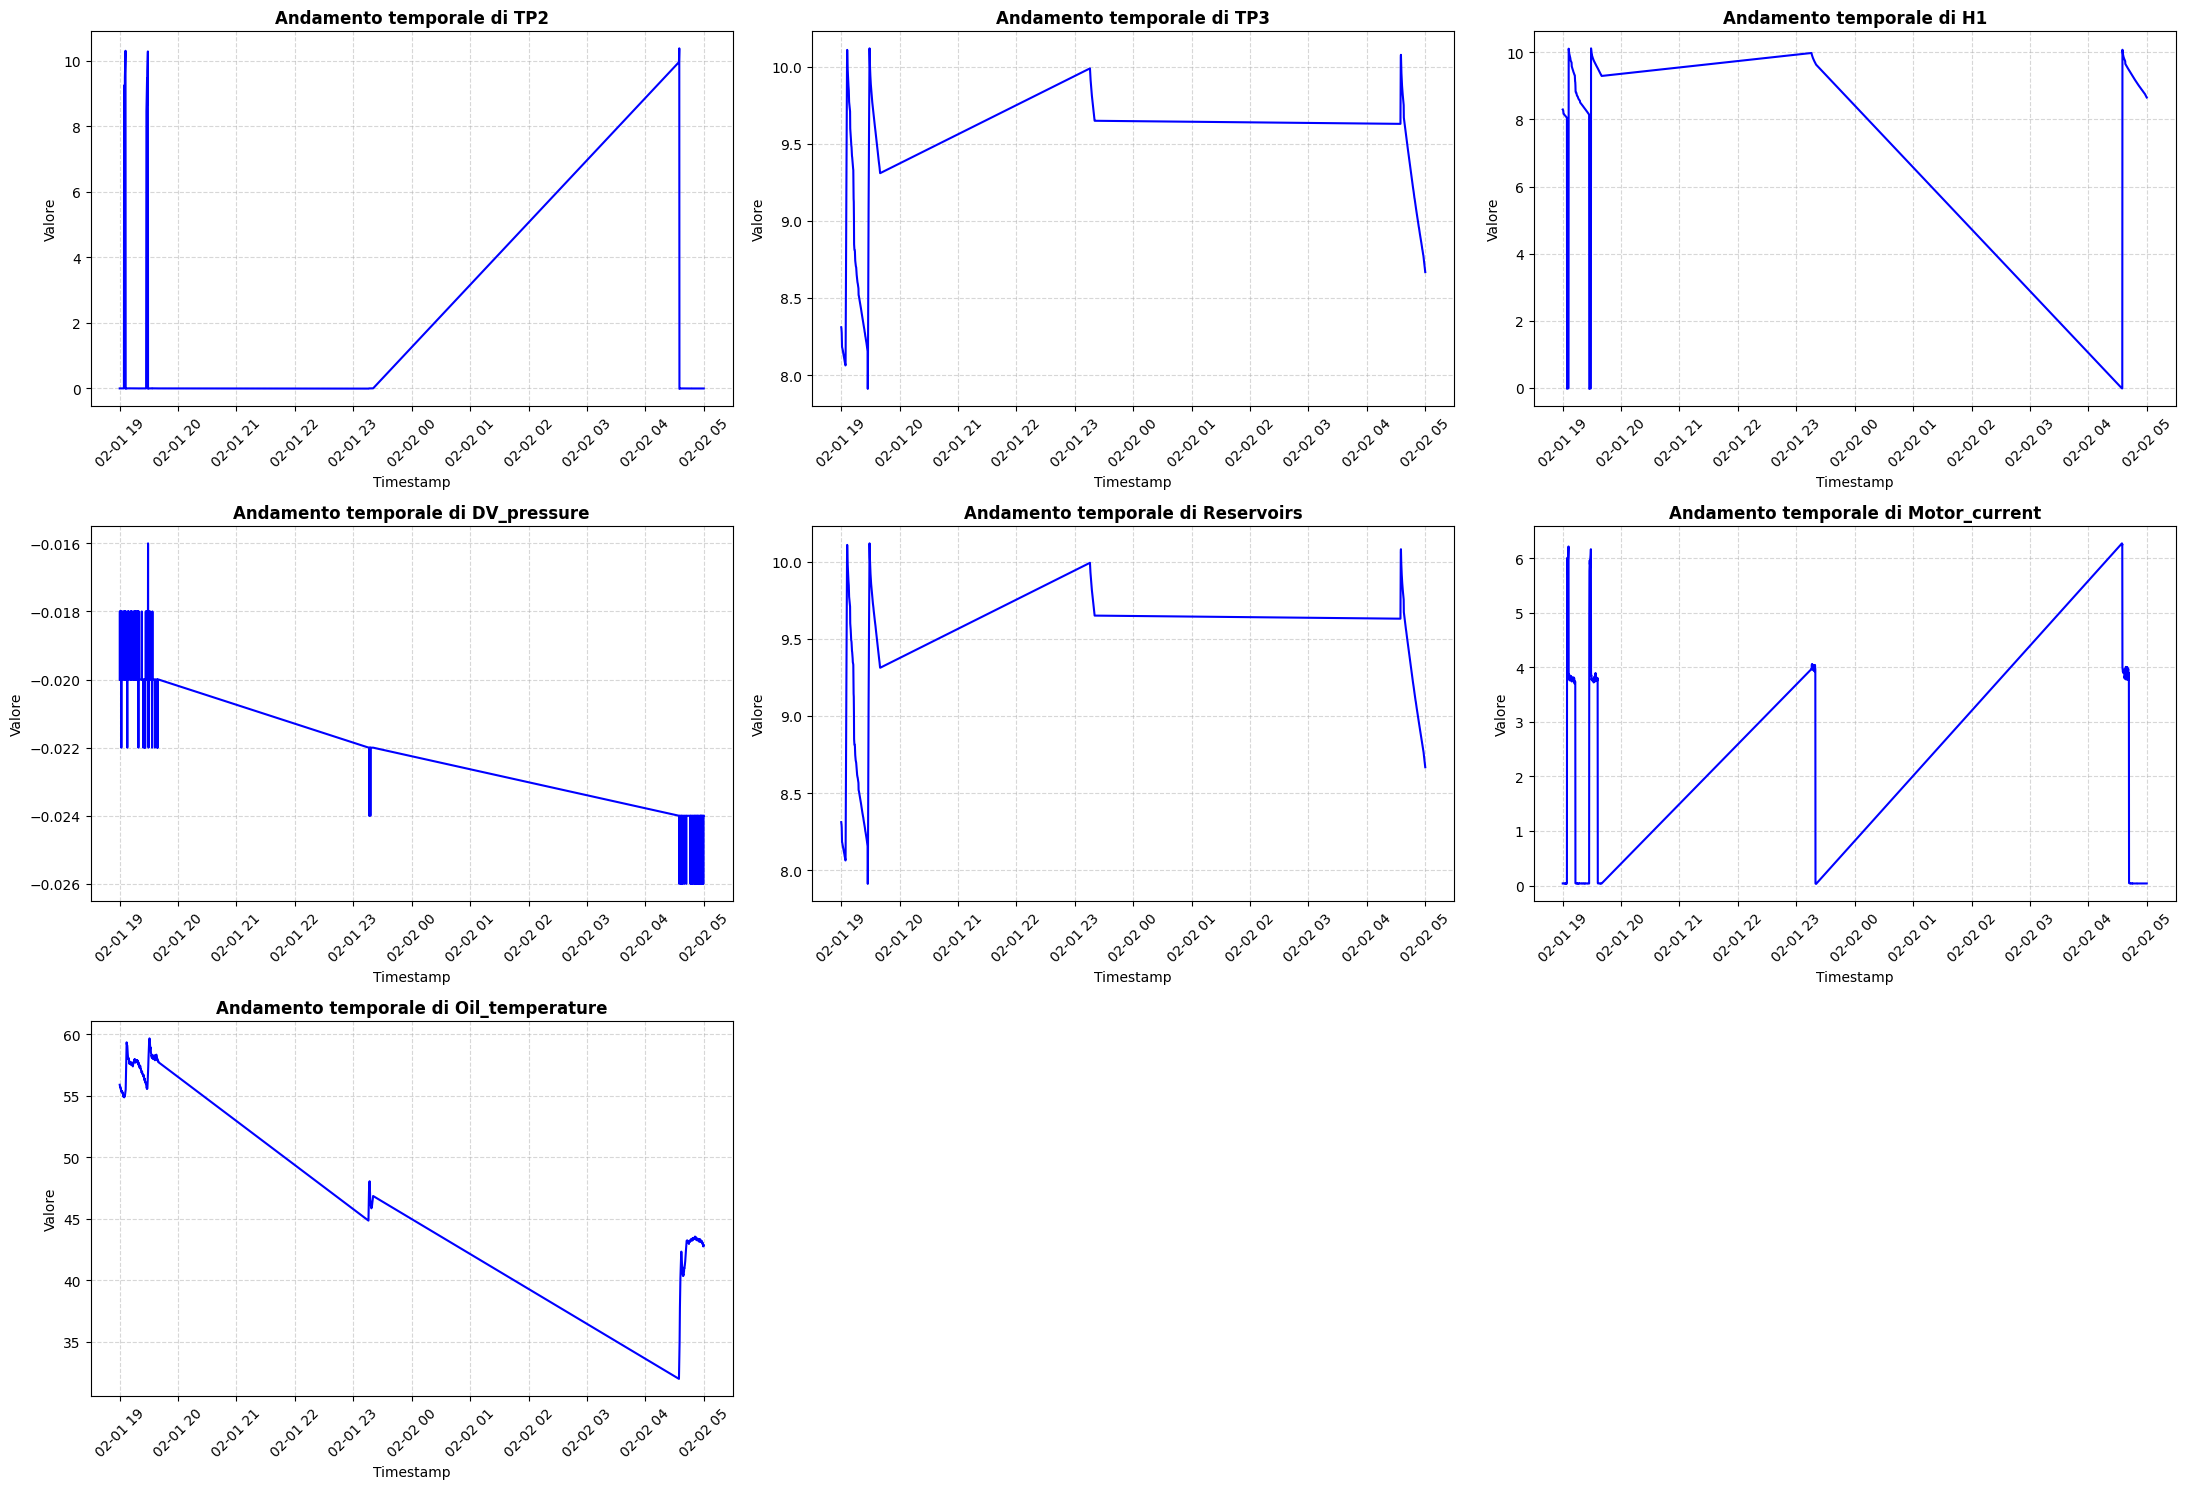

In [26]:
start_date = '2020-02-01 19:00:00'
end_date = '2020-02-02 05:00:00'

df_sub = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

fig, axes = plt.subplots(3, 3, figsize=(22, 15))

axes = axes.flatten()

for i, col in enumerate(analogici):
    # CORREZIONE: df_sub[col] SENZA VIRGOLETTE
    axes[i].plot(df_sub['timestamp'], df_sub[col], color='blue', linewidth=1.5)
    axes[i].set_title(f'Andamento temporale di {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Timestamp')
    axes[i].set_ylabel('Valore')
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Ruota le date sull'asse X di 45 gradi per non sovrapporle
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(analogici), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Evento osservato all'inizio del dataset

Nelle prime 30 ore compare un evento che coinvolge quasi tutti i sensori analogici. Nello zoom dalle 19:00 del 1 febbraio alle 05:00 del 2 febbraio, TP2 rimane vicino a zero per circa due ore e poi aumenta progressivamente. In corrispondenza di una variazione netta di TP3 e Reservoirs cambiano anche Oil_temperature, Motor_current e H1, mentre DV_pressure mostra un comportamento meno evidente.

L'evento non coincide con una delle quattro finestre di guasto documentate. Viene quindi conservato come osservazione esplorativa, senza classificarlo come malfunzionamento.

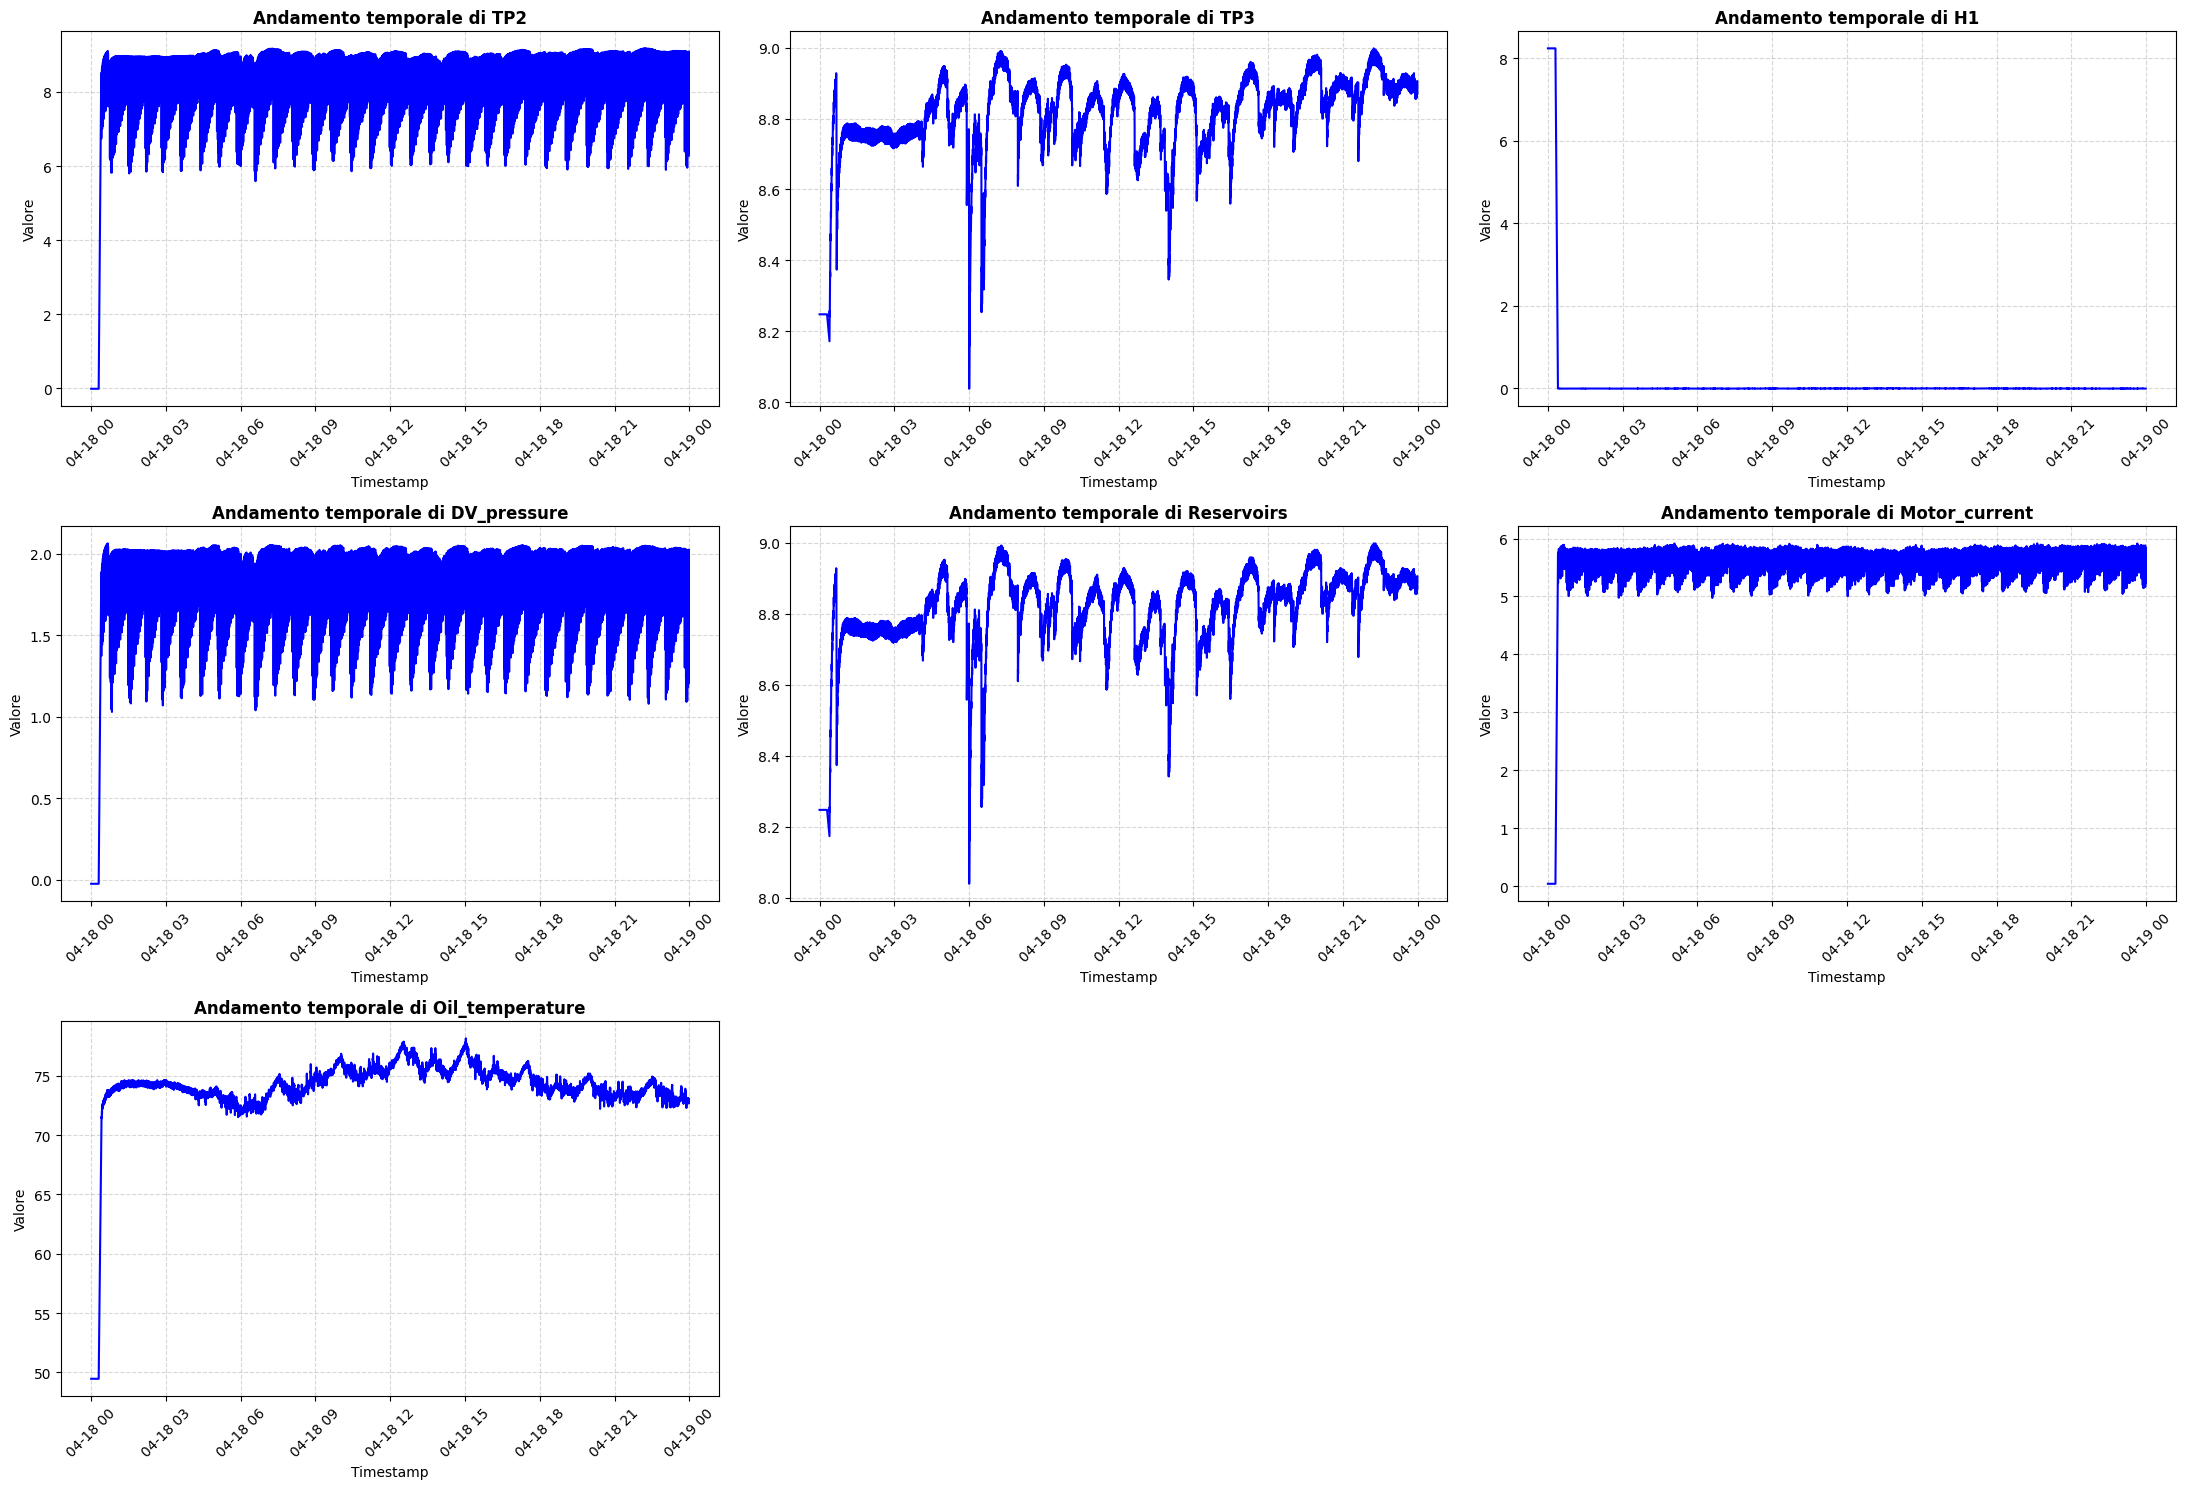

In [27]:
start_date = '2020-04-18 00:00:00'
end_date = '2020-04-18 23:59:00'

df_sub = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

fig, axes = plt.subplots(3, 3, figsize=(22, 15))

axes = axes.flatten()

for i, col in enumerate(analogici):
    # CORREZIONE: df_sub[col] SENZA VIRGOLETTE
    axes[i].plot(df_sub['timestamp'], df_sub[col], color='blue', linewidth=1.5)
    axes[i].set_title(f'Andamento temporale di {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Timestamp')
    axes[i].set_ylabel('Valore')
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Ruota le date sull'asse X di 45 gradi per non sovrapporle
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(analogici), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

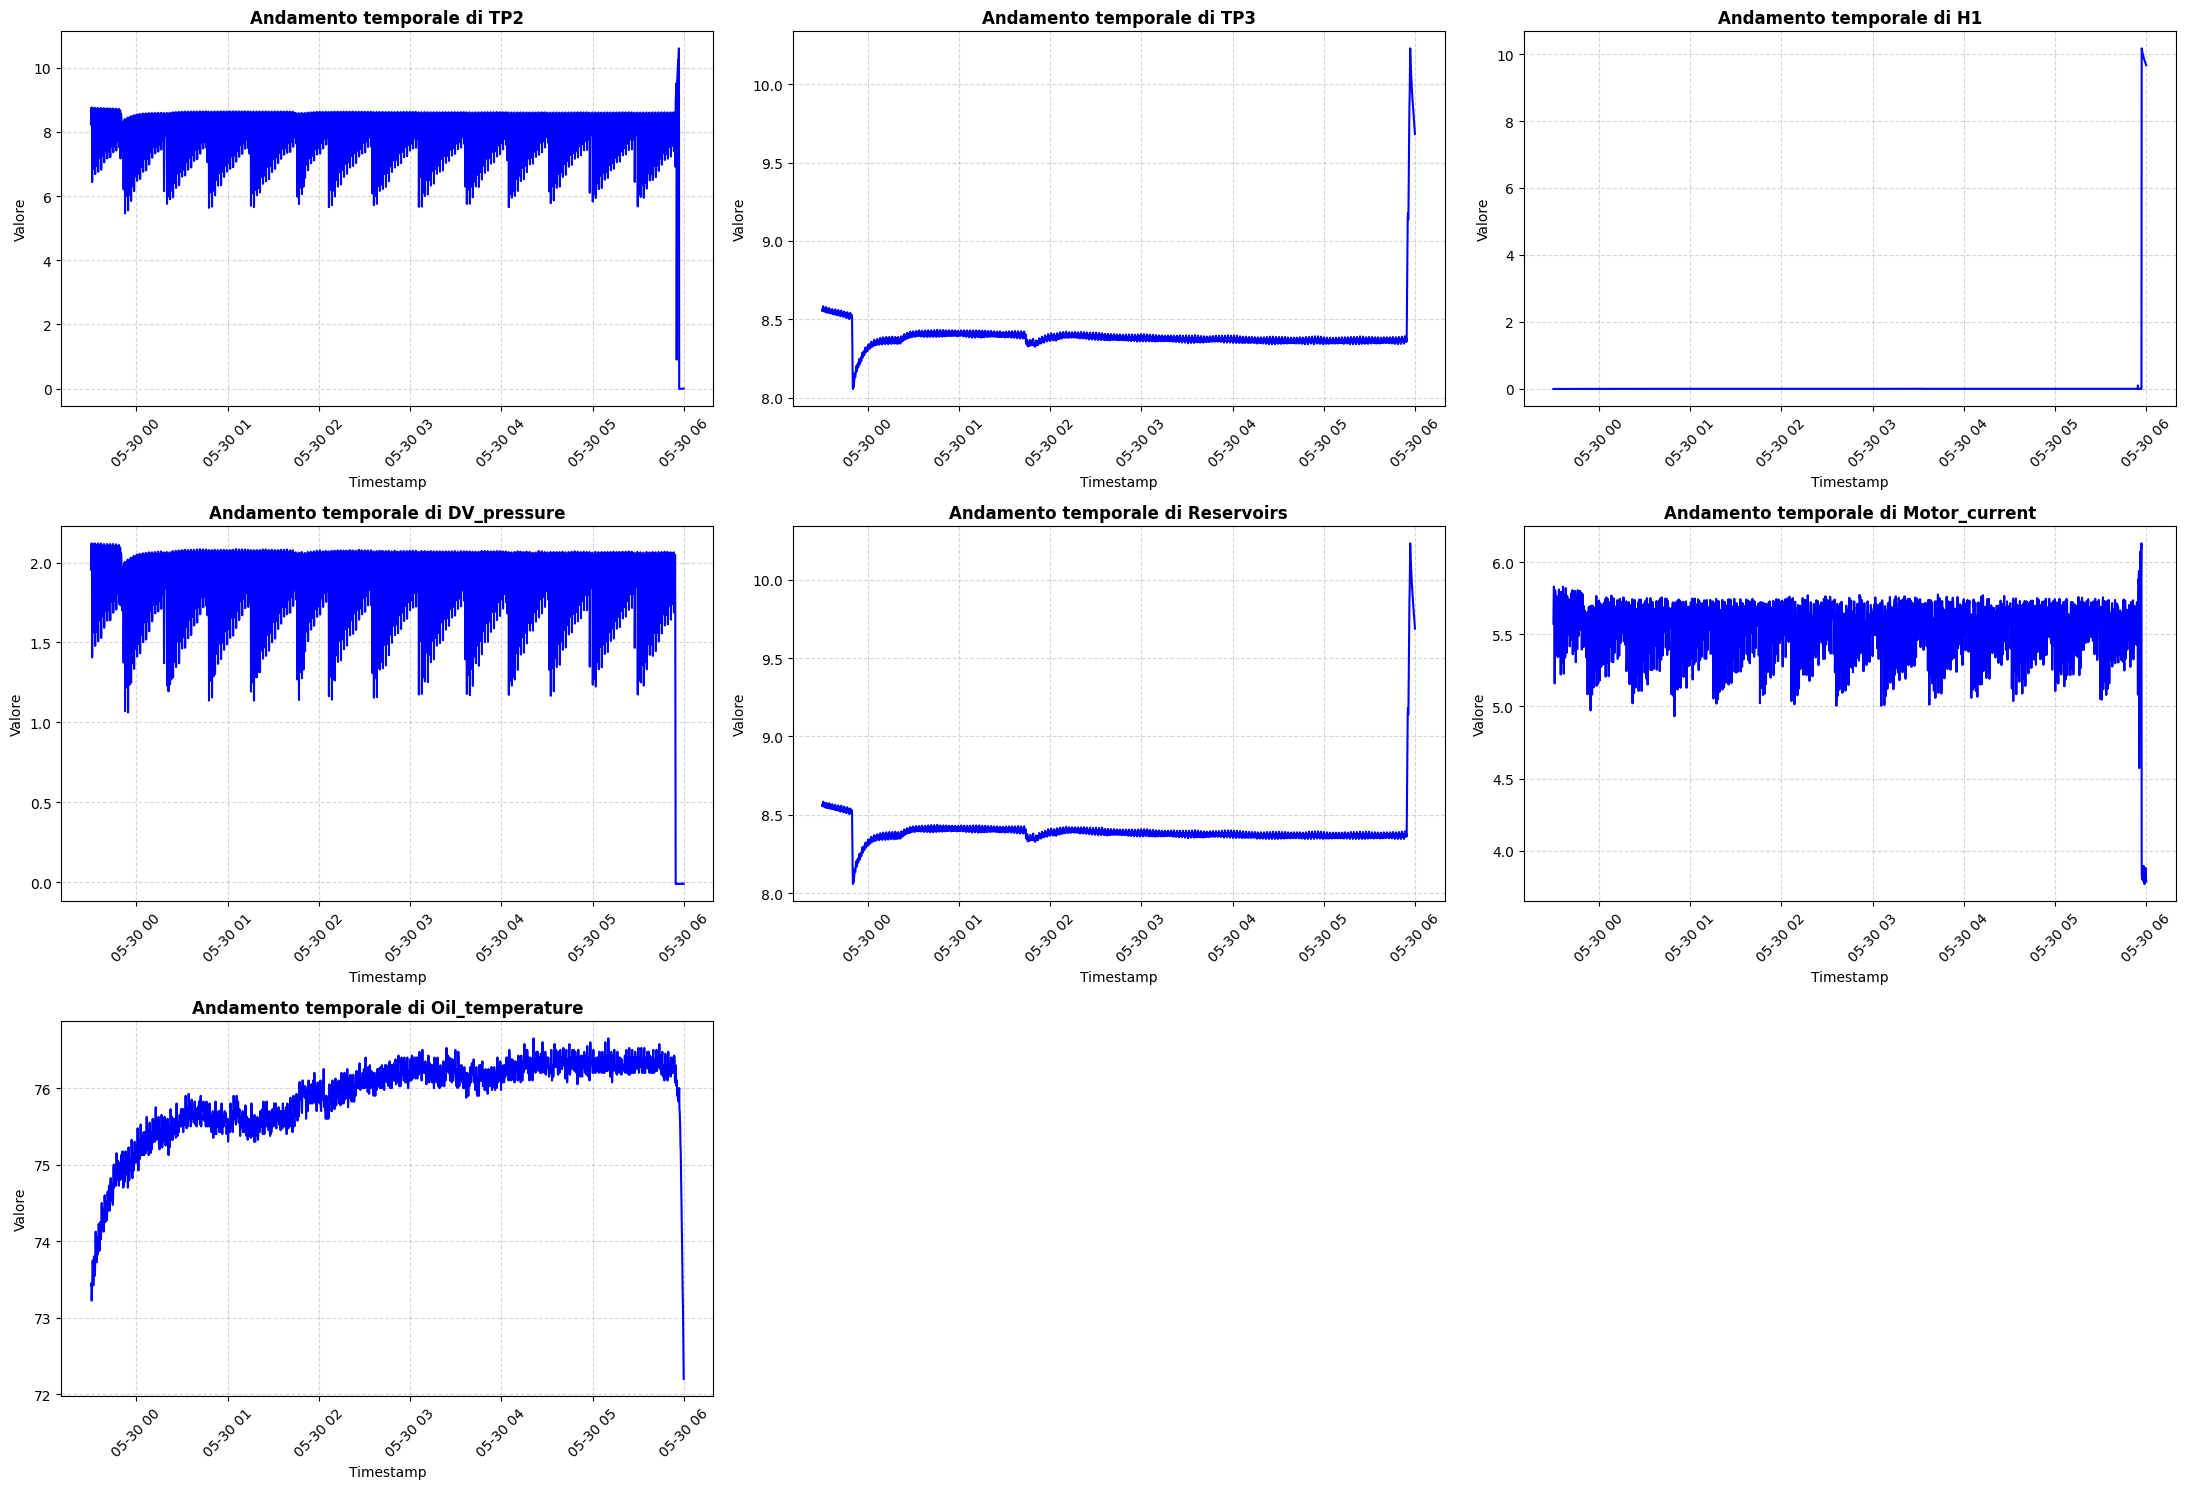

In [28]:
start_date = '2020-05-29 23:30:00'
end_date = '2020-05-30 06:00:00'

df_sub = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

fig, axes = plt.subplots(3, 3, figsize=(22, 15))

axes = axes.flatten()

for i, col in enumerate(analogici):
    # CORREZIONE: df_sub[col] SENZA VIRGOLETTE
    axes[i].plot(df_sub['timestamp'], df_sub[col], color='blue', linewidth=1.5)
    axes[i].set_title(f'Andamento temporale di {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Timestamp')
    axes[i].set_ylabel('Valore')
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Ruota le date sull'asse X di 45 gradi per non sovrapporle
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(analogici), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

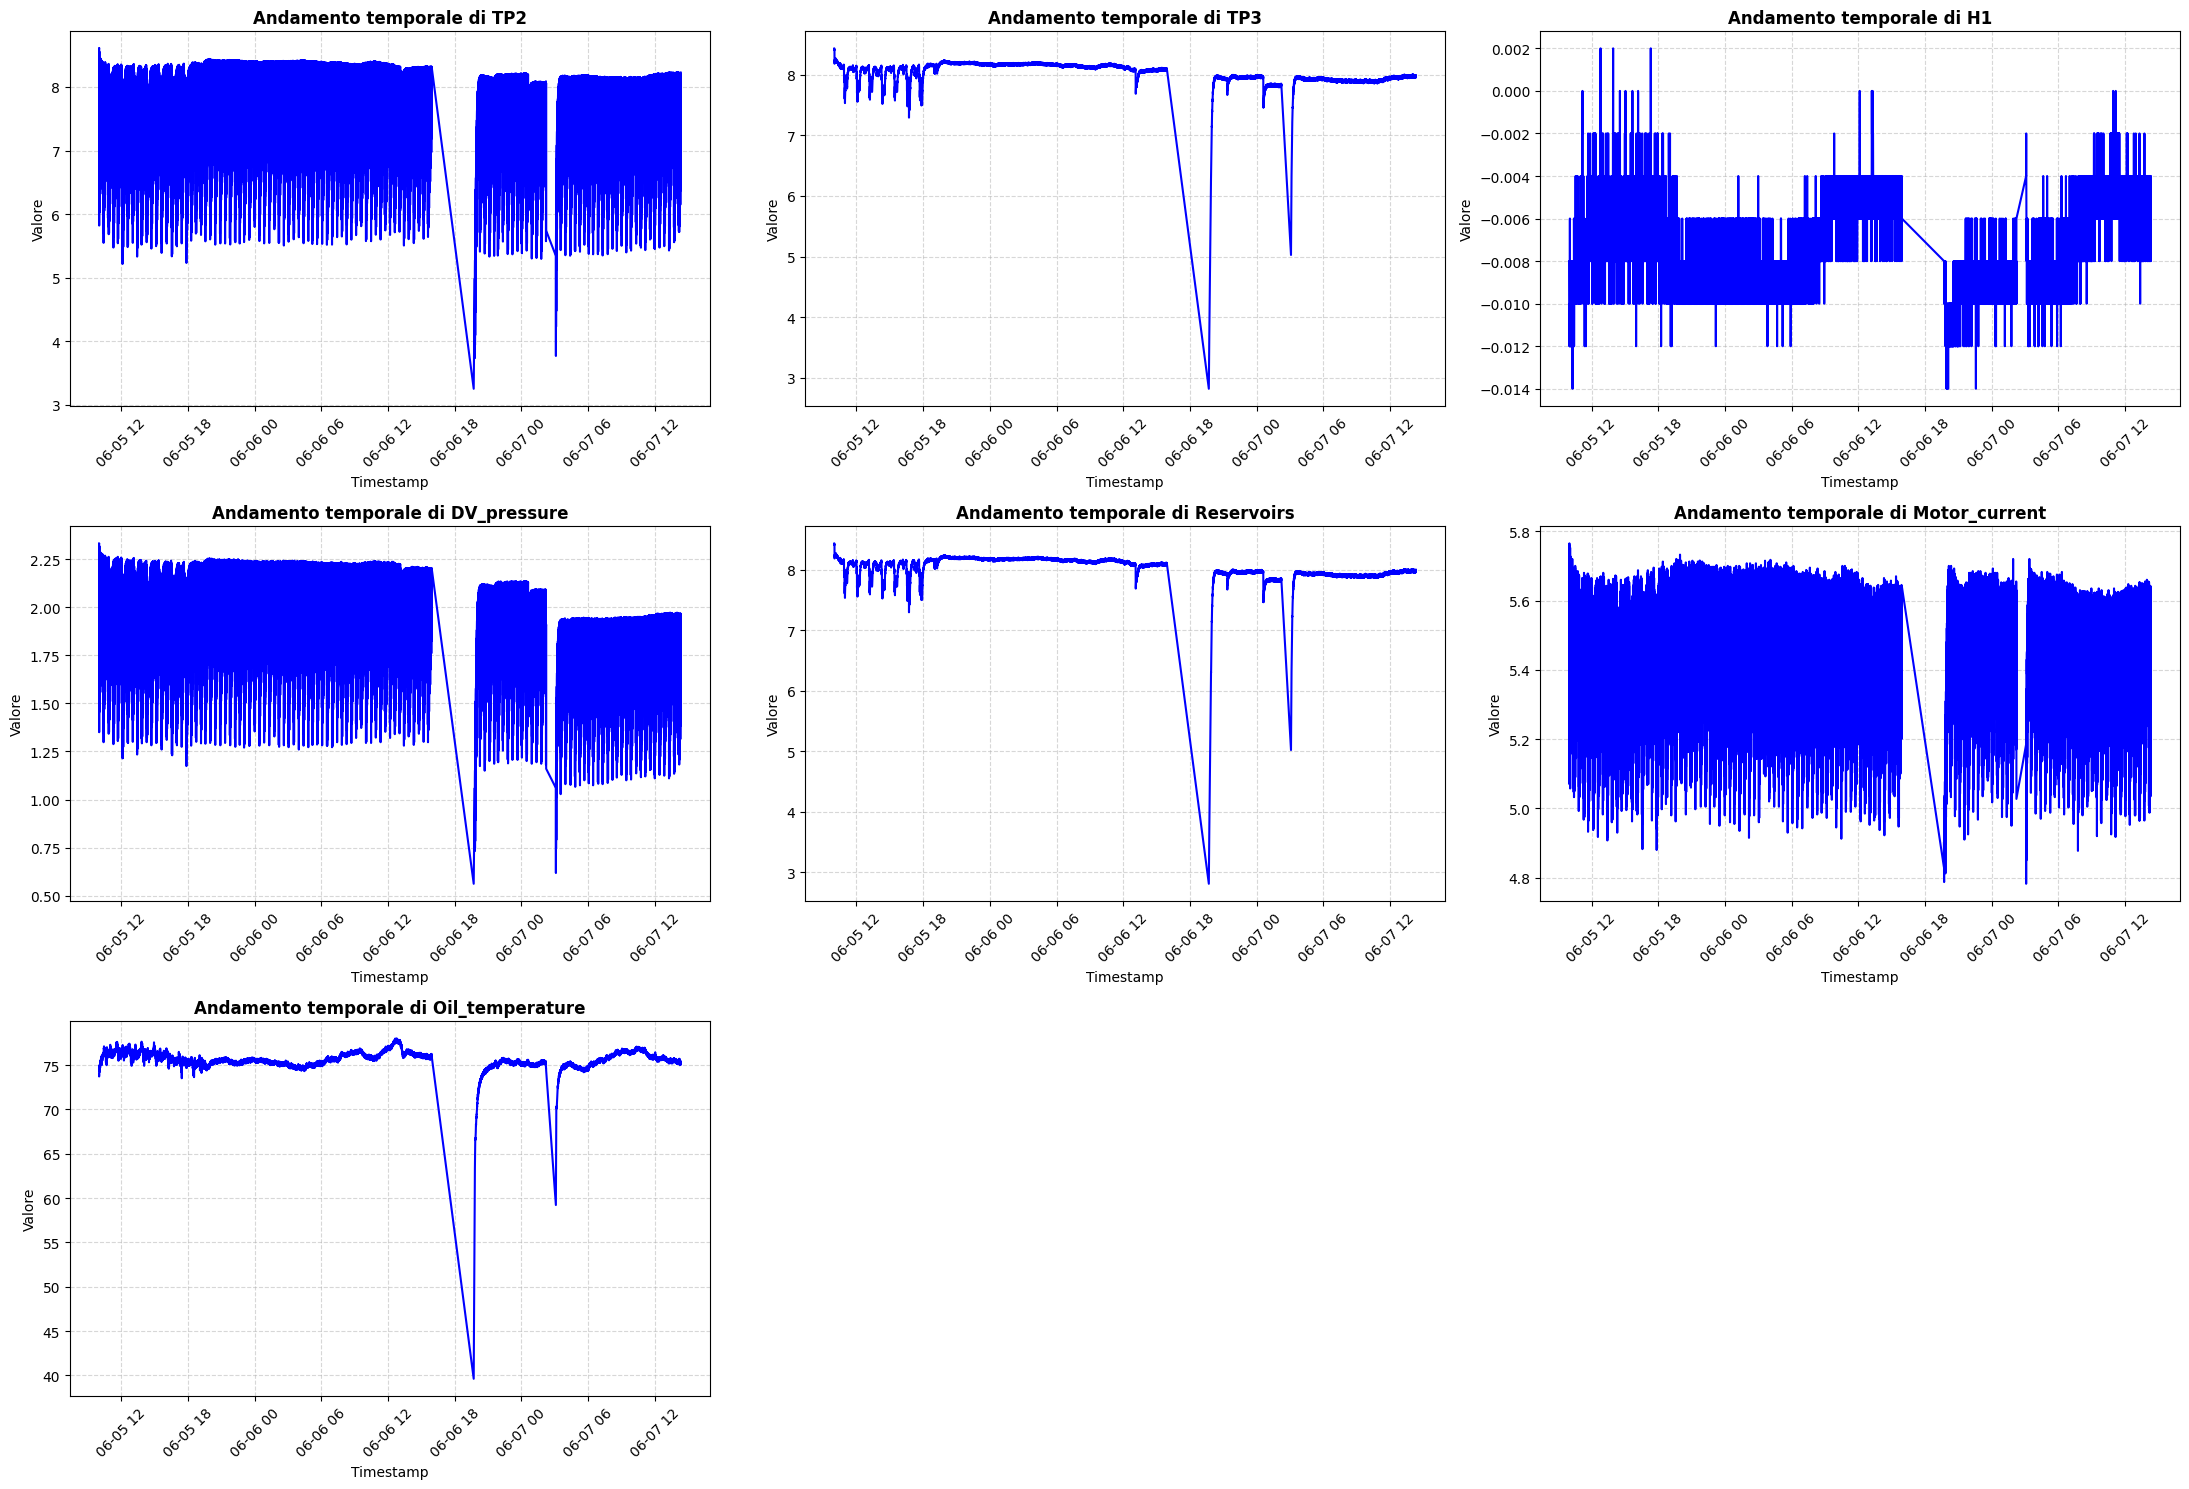

In [29]:
start_date = '2020-06-05 10:00:00'
end_date = '2020-06-07 14:30:00'

df_sub = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

fig, axes = plt.subplots(3, 3, figsize=(22, 15))

axes = axes.flatten()

for i, col in enumerate(analogici):
    # CORREZIONE: df_sub[col] SENZA VIRGOLETTE
    axes[i].plot(df_sub['timestamp'], df_sub[col], color='blue', linewidth=1.5)
    axes[i].set_title(f'Andamento temporale di {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Timestamp')
    axes[i].set_ylabel('Valore')
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Ruota le date sull'asse X di 45 gradi per non sovrapporle
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(analogici), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

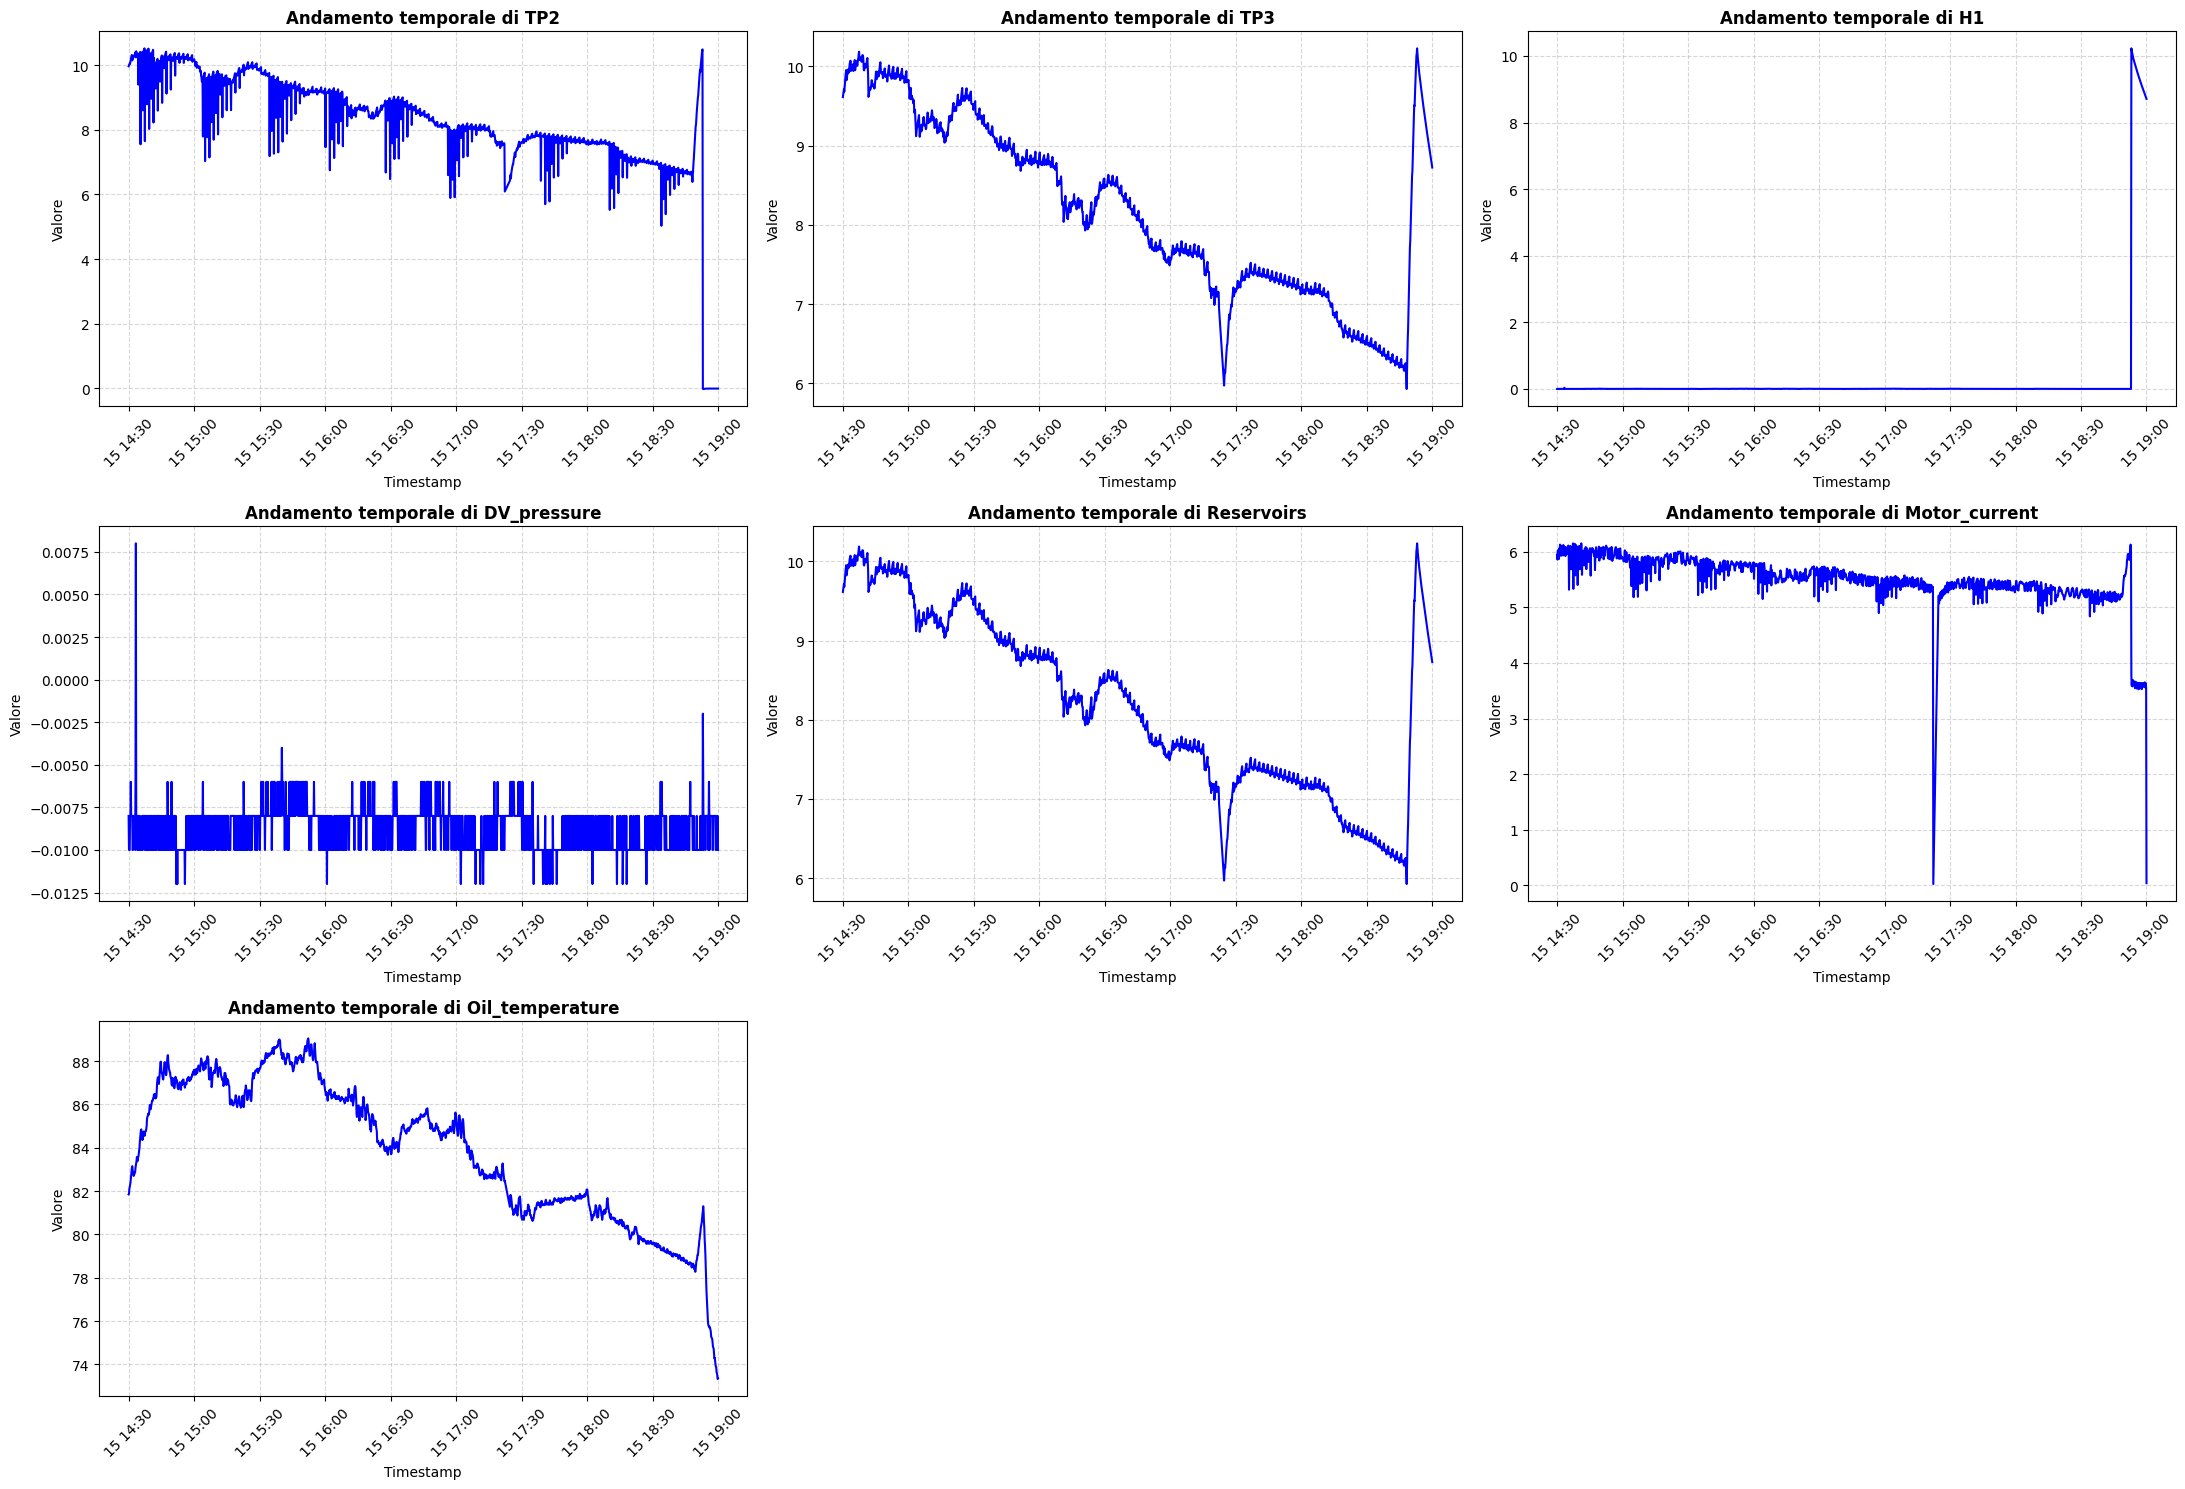

In [30]:
start_date = '2020-07-15 14:30:00'
end_date = '2020-07-15 19:00:00'

df_sub = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

fig, axes = plt.subplots(3, 3, figsize=(22, 15))

axes = axes.flatten()

for i, col in enumerate(analogici):
    # CORREZIONE: df_sub[col] SENZA VIRGOLETTE
    axes[i].plot(df_sub['timestamp'], df_sub[col], color='blue', linewidth=1.5)
    axes[i].set_title(f'Andamento temporale di {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Timestamp')
    axes[i].set_ylabel('Valore')
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Ruota le date sull'asse X di 45 gradi per non sovrapporle
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(analogici), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Confronto visuale delle quattro finestre di guasto

- TP3 e Reservoirs mostrano traiettorie visivamente molto simili in tutte le finestre, coerentemente con quanto osservato nel dataset completo.
- TP2, DV_pressure e Motor_current condividono diversi cicli operativi nelle prime tre finestre; nella quarta DV_pressure rimane invece vicino a zero mentre le pressioni principali diminuiscono.
- H1 rimane generalmente stabile o vicino a zero, con transizioni concentrate all'inizio o alla fine di alcune finestre.
- Oil_temperature segue andamenti differenti nei quattro eventi e non fornisce da sola una firma comune del guasto.

Queste sono osservazioni visuali. Per parlare di correlazione in senso statistico sarebbe necessario calcolare e confrontare coefficienti numerici in periodi normali e di guasto.

### Sensori digitali nell'intera quarta finestra di guasto

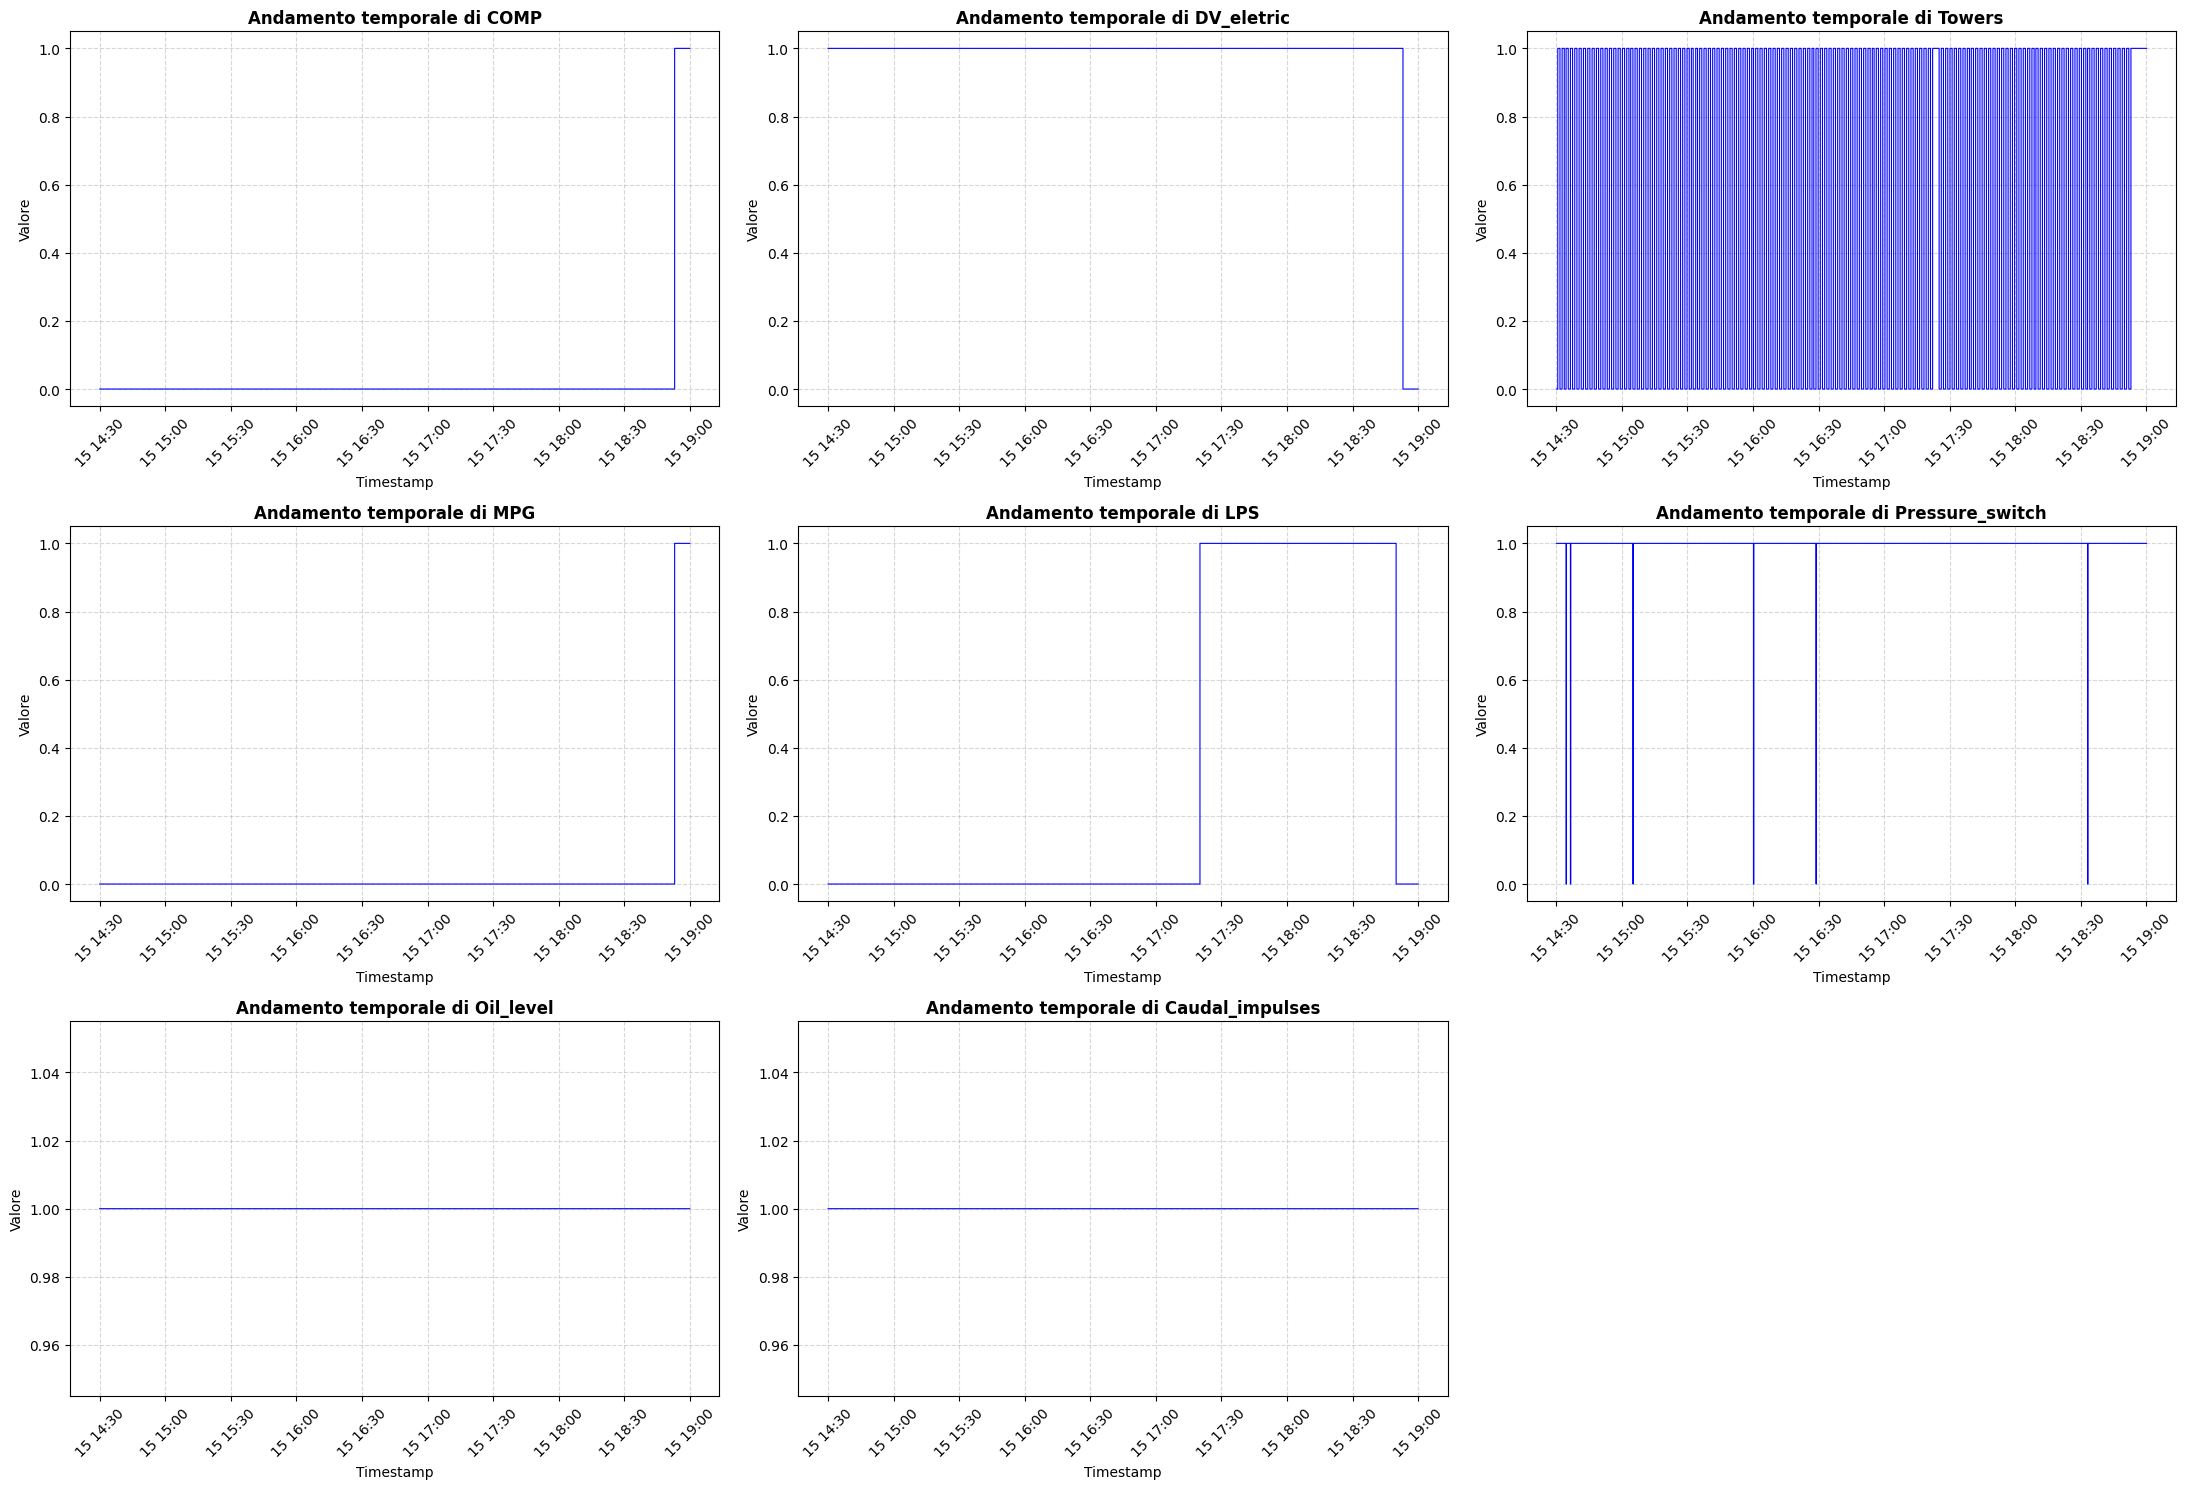

In [31]:
start_date = '2020-07-15 14:30:00'
end_date = '2020-07-15 19:00:00'

df_sub = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

fig, axes = plt.subplots(3, 3, figsize=(22, 15))
axes = axes.flatten()

for i, col in enumerate(digitali):
    axes[i].step(df_sub['timestamp'], df_sub[col], where='post', color='blue', linewidth=0.8)
    axes[i].set_title(f'Andamento temporale di {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Timestamp')
    axes[i].set_ylabel('Valore')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(digitali), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Zoom sulle transizioni digitali finali

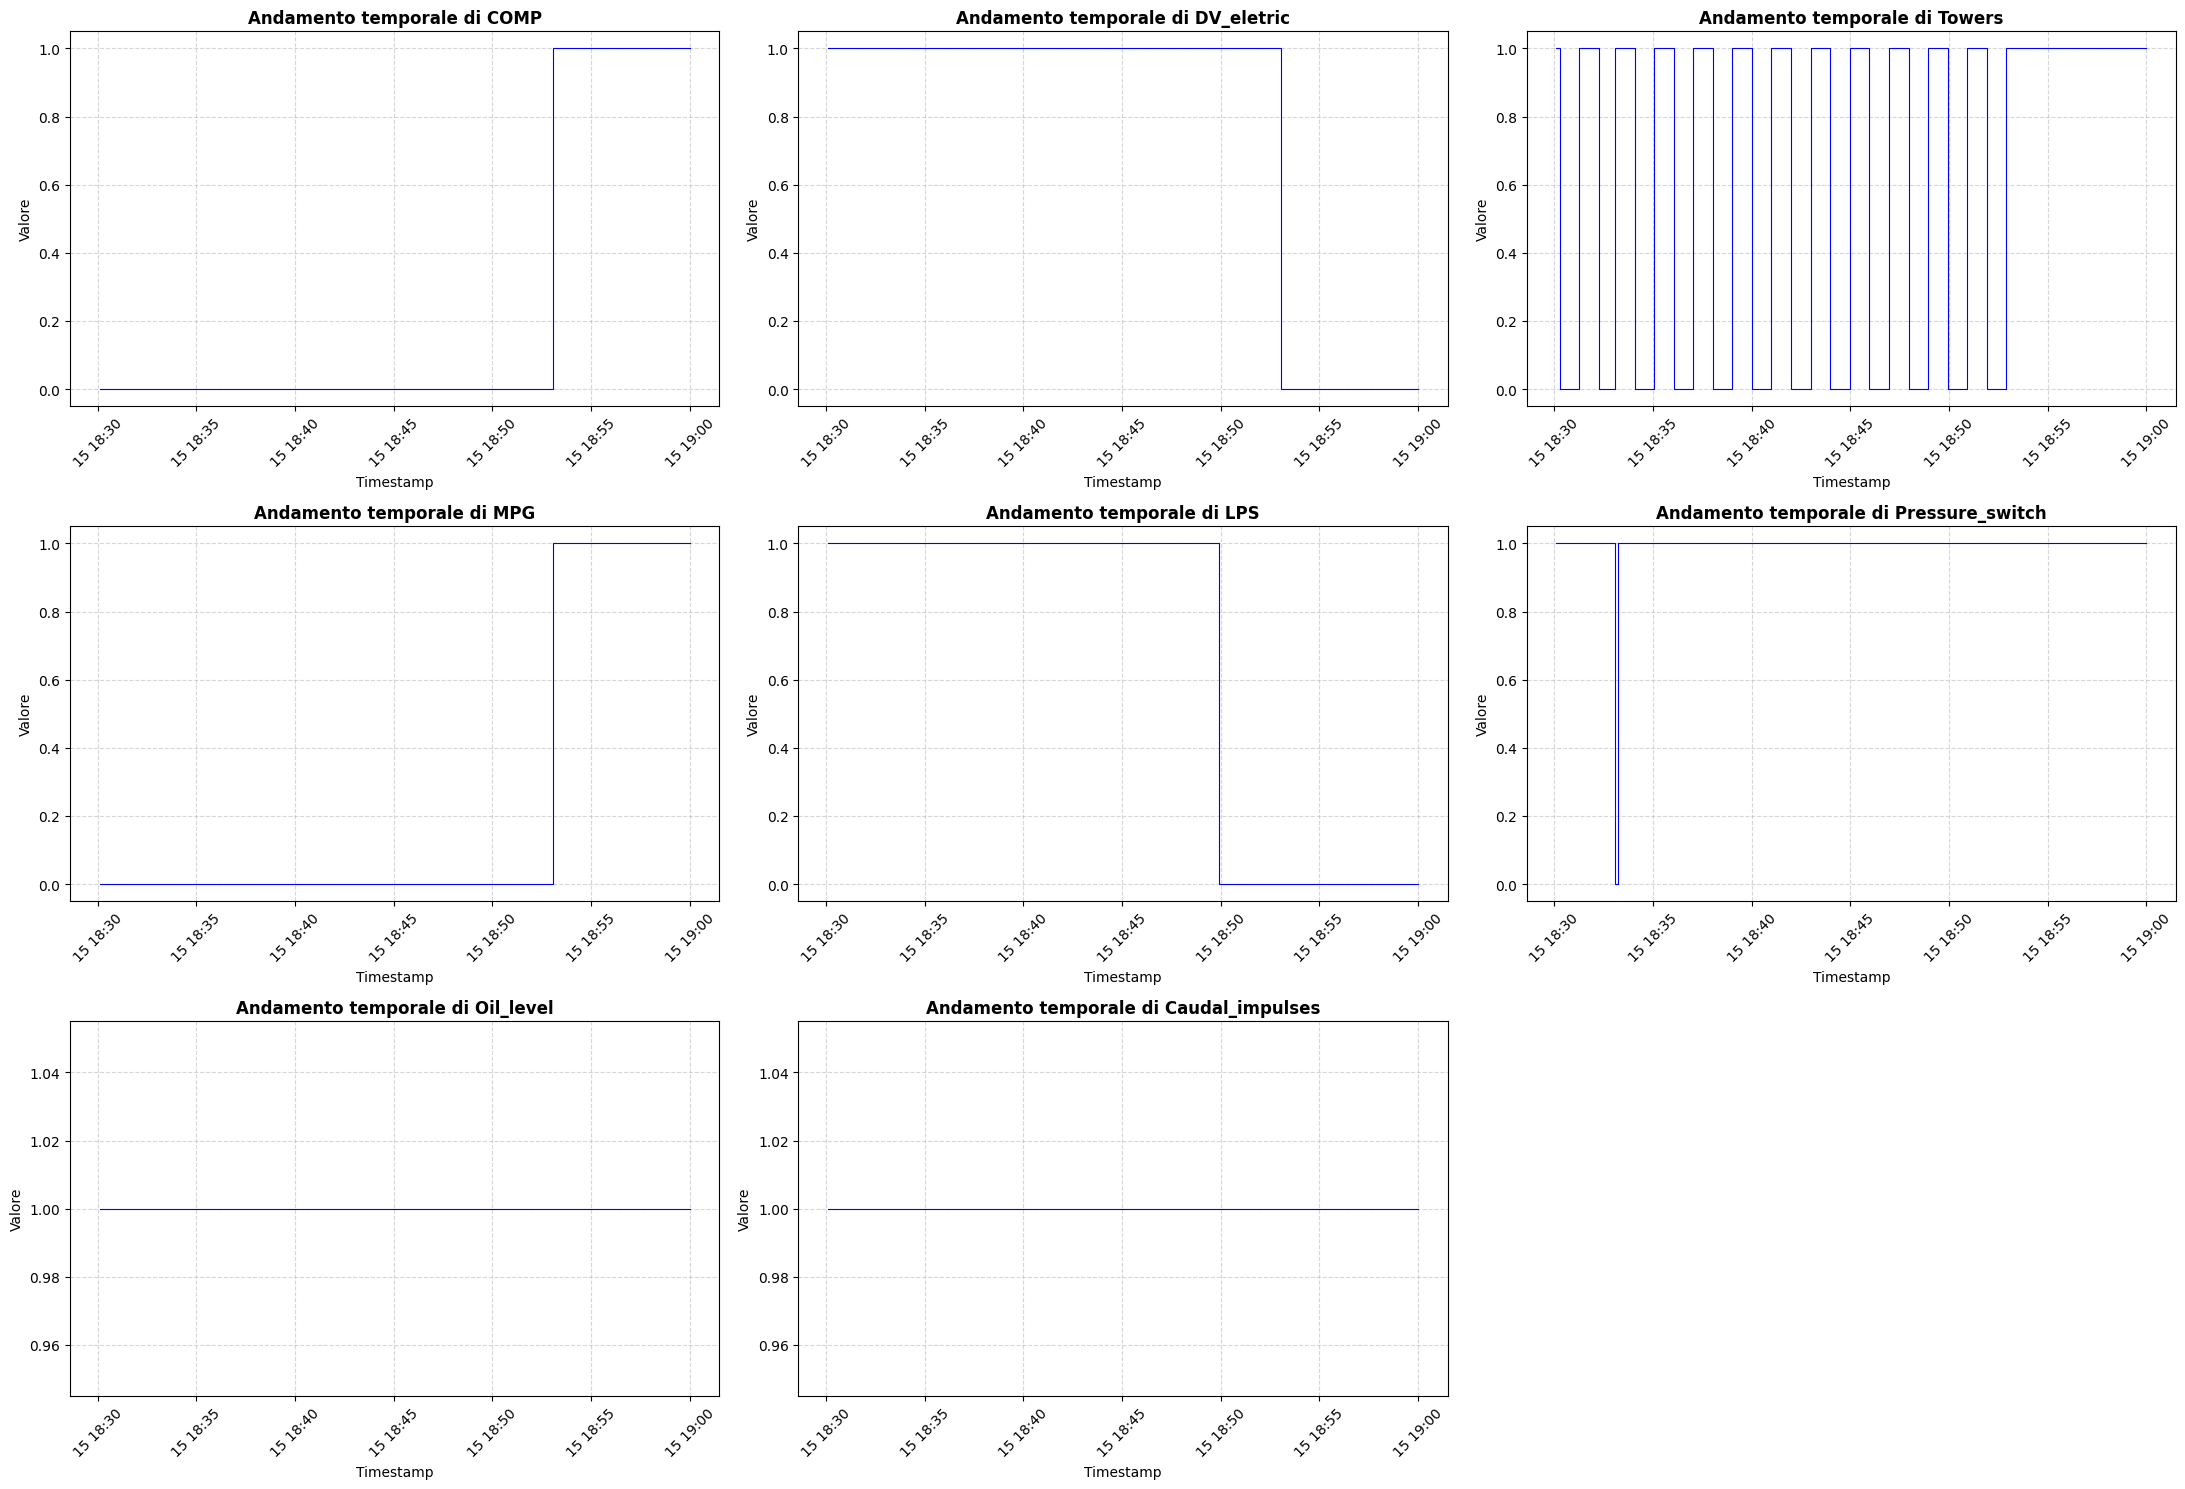

In [32]:
start_date = '2020-07-15 18:30:00'
end_date = '2020-07-15 19:00:00'

df_sub = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

fig, axes = plt.subplots(3, 3, figsize=(22, 15))

axes = axes.flatten()

for i, col in enumerate(digitali):
    # CORREZIONE: df_sub[col] SENZA VIRGOLETTE
    axes[i].step(df_sub['timestamp'], df_sub[col], where = "post", color='blue', linewidth=0.8)
    axes[i].set_title(f'Andamento temporale di {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Timestamp')
    axes[i].set_ylabel('Valore')
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Ruota le date sull'asse X di 45 gradi per non sovrapporle
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(digitali), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Osservazioni sui sensori digitali nel quarto guasto

- Nell'intera finestra LPS passa da 0 a 1 alle 17:20:11 e torna a 0 alle 18:49:56.
- COMP e MPG passano da 0 a 1 alle 18:53:04; nello stesso istante DV_eletric passa da 1 a 0.
- Towers alterna ripetutamente 0 e 1, poi rimane a 1 intorno alle 18:52.
- Pressure_switch presenta una breve transizione intorno alle 18:33.
- Oil_level e Caudal_impulses rimangono costantemente a 1 nello zoom.

Le transizioni mostrano un cambio coordinato dello stato operativo. I grafici non permettono però di identificarlo con certezza come arresto, riavvio o conseguenza diretta della perdita d'aria.

## Conclusioni sulle finestre di guasto

### Evidenze

Il CSV locale contiene 1.516.948 osservazioni, copre il periodo dal 1 febbraio al 1 settembre 2020 e presenta prevalentemente intervalli di 10 secondi. Non sono stati rilevati valori mancanti o timestamp duplicati. I sensori digitali sono binari, mentre quelli analogici mostrano regimi operativi distinti.

TP3 e Reservoirs seguono andamenti quasi sovrapposti, ma il delta dimostra che non coincidono sempre. Le quattro finestre di guasto non condividono una firma unica: il terzo evento presenta forti cali simultanei di più segnali, mentre nel quarto le pressioni principali, la corrente del motore e la temperatura dell'olio diminuiscono progressivamente prima di un cambio coordinato dei sensori digitali.

### Interpretazione

I guasti devono essere studiati come fenomeni temporali e multivariati. Un singolo valore o una singola soglia non descrivono tutti gli eventi. I sensori digitali forniscono il contesto operativo necessario per distinguere una variazione anomala da un normale cambio di regime.

### Limiti

Sono disponibili soltanto quattro finestre documentate. Una finestra di guasto può includere anche normali cicli di accensione e spegnimento, e l'osservazione grafica non dimostra rapporti di causa. Le somiglianze tra segnali sono per ora visuali: non sono stati confrontati coefficienti di correlazione tra periodi normali e periodi di guasto. Questi risultati non consentono di sostenere un'affidabilità industriale.

### Utilità per le fasi successive

Le quattro finestre serviranno per verificare se gli alert dei futuri metodi di rilevamento intercettano i guasti documentati. La pipeline dovrà conservare l'ordine temporale, rappresentare i diversi regimi dei sensori e permettere di misurare anche i falsi allarmi prodotti fuori dalle finestre note.